## Notebook Overview

# Dynex Quantum Computing - QPU Examples

All computations use Apollo QPU backend (`compute_backend="qpu"`).


## Performance Comparison: Dynex vs Other Quantum Systems


# QPU Configuration

All computations in this notebook use the following QPU parameters:

In [1]:
# QPU Parameters - Used for all examples in this notebook
QPU_MODEL = 'apollo_rc1'
QPU_MAX_COEFF = 9.0

print(f"QPU Model: {QPU_MODEL}")
print(f"QPU Max Coefficient: {QPU_MAX_COEFF}")


QPU Model: apollo_rc1
QPU Max Coefficient: 9.0


# Import Modules

In [2]:
import dynex
from dynex import DynexCircuit, DynexConfig
from pennylane import numpy as np
import pennylane as qml
import time
import matplotlib.pyplot as plt
import pandas as pd

dynex.__version__


'0.1.dev10'

____

# n-bit Adder Circuit

As of today, the largest number of bits a quantum circuit adder can handle on physical quantum hardware is severely limited by qubit count, gate fidelity, and error rates. Current gate-based quantum computers, such as those from IBM and Google, typically support reliable execution for circuits involving fewer than 20 logical qubits when accounting for error correction overhead. While some demonstrations have showcased quantum adders on **up to 4- to 6-bit numbers** using basic ripple-carry or carry-lookahead designs, practical implementations beyond that scale remain largely theoretical due to noise and decoherence. Even in ideal conditions, adding two 8-bit numbers with quantum logic would require a significant number of qubits and controlled operations, quickly exceeding today’s coherence times and error thresholds.  scalable quantum arithmetic circuits, including large-bit adders, remain an open challenge awaiting future advances in error correction and qubit scalability.

## Implementation

Quantum adder using QFT (Quantum Fourier Transform).


(<Figure size 900x500 with 1 Axes>, <Axes: >)

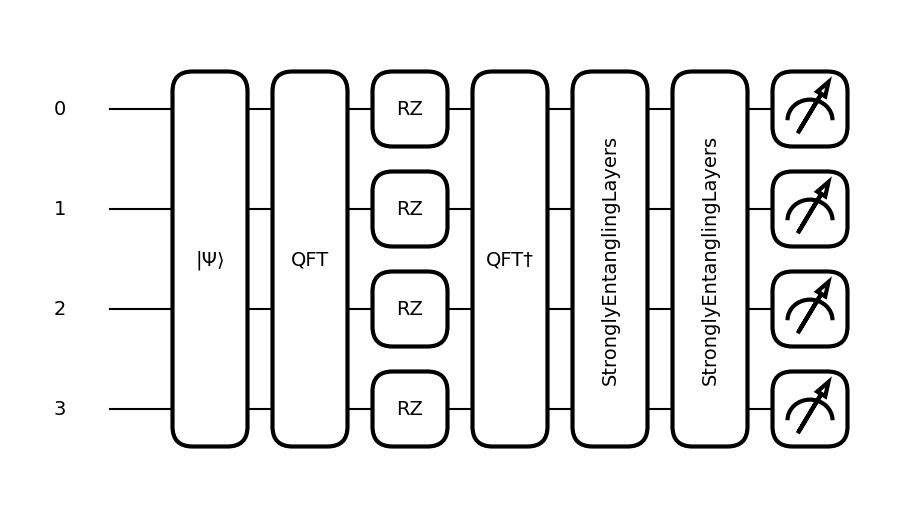

In [3]:
 # Draw the Full n-bit adder quantum circuit:

params = [12,3]; # 6 bit

def Nqubits(a, b):
    mxVal = a + b
    return mxVal.bit_length()

wires = Nqubits(*params)

def Kfourier(k, wires):
    for j in range(len(wires)):
        qml.RZ(k * np.pi / (2**j), wires=wires[j])

def FullAdder(params, state=True):
    a, b = params
    n_wires = Nqubits(a, b)
    
    # Initialize qubits with the first number
    qml.BasisEmbedding(a, wires=range(n_wires))
    
    # Apply QFT to transform to Fourier basis
    qml.QFT(wires=range(n_wires))
    
    # Apply phase rotations corresponding to the second number
    Kfourier(b, range(n_wires))
    
    # Apply inverse QFT to get back to computational basis
    qml.adjoint(qml.QFT)(wires=range(n_wires))
    
    # Now apply StronglyEntanglingLayers for testing the implementation
    # Define the number of entangling layers
    n_layers = 2
    
    # Create weights tensor with shape (n_layers, n_wires, 3)
    # Each wire needs 3 rotation angles per layer
    shape = (n_layers, n_wires, 3)
    
    # Initialize weights with specific values for detailed testing
    # First layer: gradually increasing angles through the register
    # Second layer: alternating between small and large angles
    weights = np.zeros(shape)
    for l in range(n_layers):
        for i in range(n_wires):
            if l == 0:
                # First layer: structured pattern with increasing angles
                weights[l, i, 0] = 0.1 * (i + 1)               # X rotation
                weights[l, i, 1] = np.pi/4 + 0.05 * i          # Y rotation
                weights[l, i, 2] = np.pi/2 - 0.1 * i           # Z rotation
            else:
                # Second layer: alternating pattern
                weights[l, i, 0] = np.pi/3 if i % 2 == 0 else np.pi/6    # X rotation
                weights[l, i, 1] = np.pi/4 if i % 2 == 1 else np.pi/8    # Y rotation
                weights[l, i, 2] = np.pi/2 if i % 2 == 0 else np.pi/10   # Z rotation
    
    # Define custom ranges for precise control of entanglement structure
    # Each value determines which qubits are connected in each layer
    # For example, range=2 means qubit i connects with qubit (i+2)%n_wires
    ranges = [1, 2]  # First layer: nearest neighbor, Second layer: next-nearest neighbor
    
    # Apply StronglyEntanglingLayers with CNOT as the entangling gate (default)
    qml.StronglyEntanglingLayers(
        weights=weights,
        wires=range(n_wires),
        ranges=ranges,
        imprimitive=qml.CNOT
    )
    
    # For a more comprehensive test, add another layer with a different entangler
    # This demonstrates the flexibility of the implementation
    cz_weights = np.ones((1, n_wires, 3)) * np.pi/4  # Simple uniform weights
    qml.StronglyEntanglingLayers(
        weights=cz_weights,
        wires=range(n_wires),
        ranges=[3],  # Connect qubits that are 3 positions apart
        imprimitive=qml.CZ  # Use CZ gate for entanglement
    )

    # Return the final state or measurement samples
    if state:
        return qml.state()
    else:
        return qml.sample()

qml.draw_mpl(FullAdder, style="black_white", figsize=(8, 1))(params)

We evaluate the performance of quantum adder circuits across increasing bit-widths, beginning with 6-bit additions—representing the practical upper limit of current gate-based quantum hardware—and extending to 16, 32, 64, and 100 bits. For each instance, we will assess both the correctness of the computed output and the associated execution time. The results are expected to demonstrate the system’s capability to scale significantly beyond existing quantum architectures, while maintaining extremely low error rates and achieving sub-exponential growth in time-to-solution, thereby providing strong empirical evidence of efficiency and scalability.

In [4]:
runs = [
    [12, 3],                             # 6 bit
    [128, 256],                          # 16 bit
    [10029123, 321],                     # 32 bit
    [11027172127102211, 1220],           # 64 bit
    [289384921 , 2722366482869645212131] # 100 bit
    ]

In [5]:
def run_circuit(a,b):
    from dynex import DynexConfig, DynexCircuit
    params = [a,b];
    print('-----------------------------------------------------------');
    print('Complexity:', (params[0]*params[1]).bit_length(),'bit adder');
    print('-----------------------------------------------------------');

    def Nqubits(a, b):
        mxVal = a + b
        return mxVal.bit_length()

    wires = Nqubits(*params)

    def Kfourier(k, wires):
        for j in range(len(wires)):
            qml.RZ(k * np.pi / (2**j), wires=wires[j])

    def FullAdder(params, state=True):
        a, b = params
        n_wires = Nqubits(a, b)

        # Initialize qubits with the first number
        qml.BasisEmbedding(a, wires=range(n_wires))

        # Apply QFT to transform to Fourier basis
        qml.QFT(wires=range(n_wires))

        # Apply phase rotations corresponding to the second number
        Kfourier(b, range(n_wires))

        # Apply inverse QFT to get back to computational basis
        qml.adjoint(qml.QFT)(wires=range(n_wires))

        # Return the final state
        if state:
            return qml.state()
        else:
            return qml.sample()

    # Execute the circuit on Dynex:
    config = DynexConfig(compute_backend="qpu", qpu_model=QPU_MODEL)
    dnx_circuit = DynexCircuit(config=config)
    start_time = time.time()
    measure = dnx_circuit.execute(FullAdder, params, wires, method='measure', logging=True,
                                    num_reads=1, integration_steps=100,
                                    shots=1, qpu_max_coeff=QPU_MAX_COEFF)
    end_time = time.time()
    execution_time = end_time - start_time # in s
    print('Mesaure:',measure)
    bitStr = ''.join(map(str, measure.astype(int)))
    dynexResult = int(bitStr, 2)
    print("Dynex Result:", dynexResult)
    print("Expected Result:", params[0],'+',params[1],'=',sum(params))
    isValidDynex = dynexResult == sum(params)
    if isValidDynex:
        print("✔ Valid result");
    return isValidDynex, execution_time

results = [];
for q in runs:
    is_valid, execution_time = run_circuit(q[0], q[1]);
    results.append([(q[0]*q[1]).bit_length(),is_valid, execution_time]);
for len_res, valid, exec_time in results:
    print(f"{len_res} bit adder: Valid -> {valid} ({exec_time:.2f}s)")


INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=1, shots=1, annealing_time=100
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.


-----------------------------------------------------------
Complexity: 6 bit adder
-----------------------------------------------------------


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7329)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': -1.8369701987210297e-16, 'cos_rz_1': -0.7071067811865475, 'cos_rz_2': 0.38268343236508984, 'cos_rz_3': 0.8314696123025452, 'sin_rz_0': -1, 'sin_rz_1': 0.7071067811865476, 'sin_rz_2': 0.9238795325112867, 'sin_rz_3': 0.5555702330196022}
INFO: [DYNEX-APOLLO-RC1] model: {'offset': '4.0', 'q': '789c9558416e1b310cfc4a6e6981d8a04849ebed67166e10d4015aa08d0f015af4efddc4b5454a1c6913e4e244a228723833f29f4ff7bf16594ecbcbd3f1fbfdc39dfef4f9cb5ddcd3c3dddb125eceafc79fcbf38fe3b7cb2a5e5e7e5f3eaecb76b49f72929c0f394e42619aa7cb365271e9167517ae61c3f2a88386f5e85bccb08f2172909459d6a0730a973d723bf97fba2a112e81f595827725324b482d111dc5cf2e9625ef85d167a97cd01da8def57e8b5b7db894fd51af629524ac0f99a4f5495e42309f93934ed3aeeb475d34ba5de5daf672331ca91c47fb7448d38a249932e7994adfcd16d187e7bdb01cc2fa4b2c812581e6b07b2db155168d42948d85861e8f2af4c9e4bca51961f97a3c3f9f4d791a808b095bf076fb77d35073349c82cbd11

Mesaure: [1 1 1 1]
Dynex Result: 15
Expected Result: 12 + 3 = 15
✔ Valid result
-----------------------------------------------------------
Complexity: 16 bit adder
-----------------------------------------------------------


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7330)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': 1, 'cos_rz_1': 1, 'cos_rz_2': 1, 'cos_rz_3': 1, 'cos_rz_4': 1, 'cos_rz_5': 1, 'cos_rz_6': 1, 'cos_rz_7': -1, 'cos_rz_8': 6.123233995736766e-17, 'sin_rz_0': -1.567547902908612e-14, 'sin_rz_1': -7.83773951454306e-15, 'sin_rz_2': -3.91886975727153e-15, 'sin_rz_3': -1.959434878635765e-15, 'sin_rz_4': -9.797174393178826e-16, 'sin_rz_5': -4.898587196589413e-16, 'sin_rz_6': -2.4492935982947064e-16, 'sin_rz_7': 1.2246467991473532e-16, 'sin_rz_8': 1}
INFO: [DYNEX-APOLLO-RC1] model: {'offset': '2.0', 'q': '789ca55ad96a1d4710fd15bd3901ebd24bf5969fb928c24486041cebc190907f4f5f4977a69653d3136202c6a17b6e756de7d4f2f74f9ffebcb6ebf3b7ebd73f9e7efbf4f941fcf3e75f1eeaa5b456464985eac8bd94cf0fb72b555ea9d75f9f5ebfbe6eb71ee3658c792d8c9828864cd4dfefe58f83dfbf3cfdfe7e55fc9f79355dc2fd275ed8b17a7dfdf1f46d3b357f8022a5984b4db9e5303ee4eaecd8dbbd7efdfe17bf951255aa6d8c482d979cbe3cc6fa7eb589dfdbfe35af

...

Mesaure: [1 0 0 1 1 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0]
Dynex Result: 10029444
Expected Result: 10029123 + 321 = 10029444
✔ Valid result
-----------------------------------------------------------
Complexity: 64 bit adder
-----------------------------------------------------------


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7332)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': 1, 'cos_rz_1': -1, 'cos_rz_10': -0.29615088824362384, 'cos_rz_11': 0.5932322950397998, 'cos_rz_12': 0.8925335554027646, 'cos_rz_13': 0.9727624466956886, 'cos_rz_14': 0.9931672685644872, 'cos_rz_15': 0.9982903556993044, 'cos_rz_16': 0.9995724975456518, 'cos_rz_17': 0.9998931186746041, 'cos_rz_18': 0.9999732793116535, 'cos_rz_19': 0.9999933198056009, 'cos_rz_2': -4.41677522520612e-15, 'cos_rz_20': 0.9999983299500057, 'cos_rz_21': 0.9999995824874143, 'cos_rz_22': 0.9999998956218481, 'cos_rz_23': 0.9999999739054617, 'cos_rz_24': 0.9999999934763654, 'cos_rz_25': 0.9999999983690914, 'cos_rz_26': 0.9999999995922728, 'cos_rz_27': 0.9999999998980682, 'cos_rz_28': 0.999999999974517, 'cos_rz_29': 0.9999999999936293, 'cos_rz_3': 0.7071067811865459, 'cos_rz_30': 0.9999999999984073, 'cos_rz_31': 0.9999999999996019, 'cos_rz_32': 0.9999999999999004, 'cos_rz_33': 0.9999999999999751,

Mesaure: [1 0 0 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 0 1 1 1 1 0 0 1 0 1 0 1 1 0 0 0 0 0 1
 1 0 1 0 1 1 0 0 1 1 1 0 0 0 1 1 1]
Dynex Result: 11027172127103431
Expected Result: 11027172127102211 + 1220 = 11027172127103431
✔ Valid result
-----------------------------------------------------------
Complexity: 100 bit adder
-----------------------------------------------------------


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7333)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': 0.8488523815916276, 'cos_rz_1': 0.9614708476057992, 'cos_rz_10': -0.8873889876367417, 'cos_rz_11': -0.23728781296482365, 'cos_rz_12': 0.6175403578047253, 'cos_rz_13': 0.899316506521682, 'cos_rz_14': -0.9745041063334936, 'cos_rz_15': -0.11290680596515512, 'cos_rz_16': -0.6659929406663575, 'cos_rz_17': -0.4086606534361012, 'cos_rz_18': 0.5437551593152468, 'cos_rz_19': 0.8785656376490167, 'cos_rz_2': -0.9903208691140966, 'cos_rz_20': 0.9691660429588463, 'cos_rz_21': -0.9922615690831844, 'cos_rz_22': -0.062203018081181484, 'cos_rz_23': -0.6847616307587694, 'cos_rz_24': -0.3970128267708933, 'cos_rz_25': -0.5490843164893288, 'cos_rz_26': 0.4748240113508747, 'cos_rz_27': 0.8587269680611163, 'cos_rz_28': 0.9640350014551121, 'cos_rz_29': -0.9909679615040822, 'cos_rz_3': 0.06956698529440328, 'cos_rz_30': -0.06720133367693616, 'cos_rz_31': 0.6829343549430882, 'cos_rz_32': 0.91

Mesaure: [1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0
 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0]
Dynex Result: 2722366482869934597052
Expected Result: 289384921 + 2722366482869645212131 = 2722366482869934597052
✔ Valid result
6 bit adder: Valid -> True (13.54s)
16 bit adder: Valid -> True (5.89s)
32 bit adder: Valid -> True (3.98s)
64 bit adder: Valid -> True (3.86s)
100 bit adder: Valid -> True (5.20s)


## Plot results

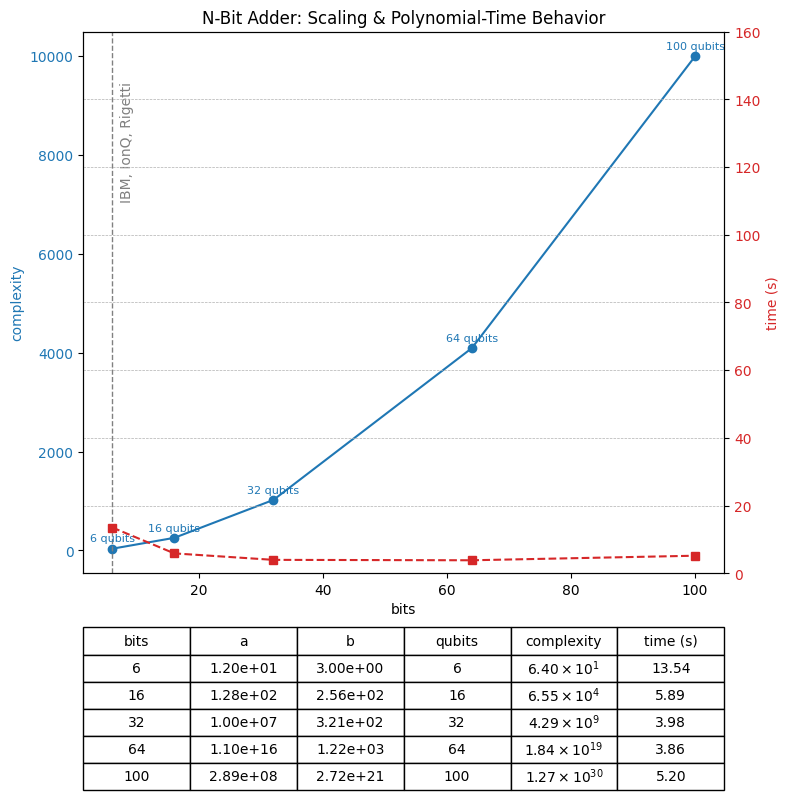

In [6]:
# Check if results is empty
if not results or len(results) == 0:
    raise ValueError("results is empty! Please run cell 15 first to populate results.")

data = results
n_values = [row[0] for row in data]
time_seconds = [row[2] for row in data]
complexity = [n**2 for n in n_values]
a_values = [row[0] for row in runs]
b_values = [row[1] for row in runs]

# Compute y-limits
max_complexity = max(complexity)
max_time = max(time_seconds)
time_ylim = (0, 150)  

# Compute proportional Y-axis scaling factor
scale_factor = (time_ylim[1] - time_ylim[0]) / (max_time - 0) 

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left Y-axis: quantum gates
color1 = 'tab:blue'
ax1.set_xlabel('bits')
ax1.set_ylabel('complexity', color=color1)
ax1.plot(n_values, complexity, 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
#ax1.set_ylim(complexity_ylim)

# Add vertical lines with labels
ax1.axvline(x=6, color='gray', linestyle='--', linewidth=1)
ax1.text(6 + 1.3, max_complexity * 0.95, 'IBM, IonQ, Rigetti', rotation=90, verticalalignment='top', color='gray')

# Right Y-axis: time in seconds (real values), visually scaled
color2 = 'tab:red'
ax2 = ax1.twinx()
ax2.set_ylabel('time (s)', color=color2)
scaled_time = [t * scale_factor for t in time_seconds]
ax2.plot(n_values, scaled_time, 's--', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(time_ylim)

# Set tick positions (in scaled units)
ax2.set_yticks([scale_factor * t for t in ax2.get_yticks()])
ax2.set_yticklabels([f"{t / scale_factor:.0f}" for t in ax2.get_yticks()])

# annotate qubit counts:
for i, n in enumerate(n_values):
    ax1.annotate(f"{n:,} qubits", (n, complexity[i]), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, color=color1)

plt.title('N-Bit Adder: Scaling & Polynomial-Time Behavior')
plt.grid(True, linestyle='--', linewidth=0.5)
fig.tight_layout()


# Data Table:
df = pd.DataFrame({
    'bits': n_values,
    'a': [f"{a:.2e}" for a in a_values],
    'b': [f"{b:.2e}" for b in b_values],
    'qubits': [f"{n:,}" for n in n_values],
    'complexity': [
    r"$%.2f \times 10^{%d}$" % (float(mantissa), int(exponent))
    for n in n_values
    for mantissa, exponent in [f"{2**int(n):.2e}".split("e")]
],
    'time (s)': [f"{t:.2f}" for t in time_seconds]
})

# Add table below plot
table = plt.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.4, 1, 0.3]  # [left, bottom, width, height]
)

# Adjust layout to make space for the table
plt.subplots_adjust(bottom=0.035)


plt.show()

_____

# Travelling Salesman Problem

Travelling Salesman Problem - find shortest route visiting all cities.


## Implementation

TSP is formulated as a QUBO problem for quantum annealing.


We evaluate the performance of our system on the TSP problem across increasing numbers of cities (e.g., n=50, n=60, up to n=80), systematically measuring the effective time-to-solution (TTS). The results demonstrate that, despite the exponential growth in problem complexity with respect to n, the observed TTS scales sub-exponentially and aligns with polynomial-time behavior. This empirical evidence indicates a quantum computational advantage for this class of combinatorial problems under increasing input sizes.

In [7]:
runs = [
    [ 5, 1, 100, 0.7],
    [10, 1, 100, 0.7],
    [20, 1, 100, 0.7], # 20 cities
    # [50, 10, 1000, 1.7],  # 50 cities TOO LONG (TIMED OUT)
    # [80, 10, 1000, 1.7],  # 80 cities TOO LONG (TIMED OUT)
]

In [8]:
import matplotlib.pyplot as plt


def tsp_to_bqm(dist_matrix, A):
    """
    Converts the Traveling Salesperson Problem (TSP) to a Binary Quadratic Model (BQM).

    Variables:
    x_u,p = 1 if city u is visited at step p, 0 otherwise.
    The number of variables is n*n.

    Objective:
    Minimize the total distance of the tour.
    Sum(dist_u,v * x_u,p * x_v,p+1) for all u, v, p.

    Constraints (added as penalties with multiplier A):
    1. Each city must be visited exactly once: Sum(x_u,p for p=0..n-1) = 1 for each city u.
    2. Each step in the tour must contain exactly one city: Sum(x_u,p for u=0..n-1) = 1 for each step p.
    """
    n = len(dist_matrix)
    bqm = dimod.BinaryQuadraticModel({}, {}, 0.0, dimod.BINARY)

    # --- Objective: Minimize tour distance ---
    # We add the cost for traveling between cities at consecutive steps.
    for u in range(n):
        for v in range(n):
            if u == v:
                continue
            for p in range(n):
                # Interaction for city u at step p and city v at step p+1
                # The modulo % n handles the wrap-around from the last city back to the first.
                var1 = u * n + p
                var2 = v * n + ((p + 1) % n)
                bqm.add_interaction(var1, var2, dist_matrix[u][v])

    # --- Constraints ---
    # Using dimod's built-in function for linear equality constraints.
    # This is equivalent to adding A * (sum(vars) - 1)^2 to the BQM.

    # 1. Each city must be visited exactly once.
    for u in range(n):
        city_vars = [(u * n + p, 1.0) for p in range(n)]
        bqm.add_linear_equality_constraint(
            city_vars,
            constant=-1.0,
            lagrange_multiplier=A
        )

    # 2. Each step must be assigned to exactly one city.
    for p in range(n):
        step_vars = [(u * n + p, 1.0) for u in range(n)]
        bqm.add_linear_equality_constraint(
            step_vars,
            constant=-1.0,
            lagrange_multiplier=A
        )

    return bqm


def visualize_tsp(coords, path, total_dist):
    """
    Visualizes the TSP solution by plotting cities and the tour path.
    """
    n = len(coords)
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot cities as points
    ax.scatter(coords[:, 0], coords[:, 1], c='blue', s=100, zorder=3)
    for i in range(n):
        ax.text(coords[i, 0] + 0.02, coords[i, 1] + 0.02, str(i), fontsize=12)

    # Plot the tour path
    if path:
        # Create a closed loop from the path
        path_coords = coords[path + [path[0]]]
        ax.plot(path_coords[:, 0], path_coords[:, 1], 'r-', zorder=2, linewidth=1.5, label=f'Total Distance: {total_dist:.2f}')

    ax.set_title(f'TSP Solution for {n} Cities')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    return fig

def solve_tsp(n_cities, num_reads=10, annealing_time=600, shots=1, LAGRANGE_MULTIPLIER_FACTOR = 1.7):
    """
    Solves the TSP for a given number of cities using the Dynex Quantum Annealer.
    """
    print("---------------------------------------------");
    print(f"[TSP] Starting TSP for N={n_cities} cities.")
    print("---------------------------------------------");

    # --- 1. Generate a problem instance ---
    coords = np.random.rand(n_cities, 2)*100

    # Create the distance matrix (Euclidean distance)
    dist_matrix = np.zeros((n_cities, n_cities))
    for i in range(n_cities):
        for j in range(i, n_cities):
            dist = np.linalg.norm(coords[i] - coords[j])
            dist_matrix[i][j] = dist_matrix[j][i] = dist

    # --- 2. Create the BQM ---
    lagrange_multiplier = n_cities * np.max(dist_matrix) * LAGRANGE_MULTIPLIER_FACTOR
    print(f"[BQM] Using Lagrange multiplier A = {lagrange_multiplier:.2f}")

    try:
        bqm = tsp_to_bqm(dist_matrix, lagrange_multiplier)
        model = dynex.BQM(bqm)
    except Exception as e:
        print(f"[ERROR] Error creating BQM model: {e}")
        return

    # --- 3. Sample using Dynex ---
    config = DynexConfig(compute_backend="qpu", qpu_model=QPU_MODEL)
    sampler = dynex.DynexSampler(model, config=config, description='Dynex SDK Job')

    start_time = time.time()
    sampleset = sampler.sample(
            num_reads=num_reads,
            annealing_time=annealing_time,
            debugging=False,
            shots=shots,
            qpu_max_coeff=QPU_MAX_COEFF
        )
    end_time = time.time()
    execution_time = end_time - start_time # in s

    # --- 4. Decode and Validate the Solution ---
    solution = sampleset.first.sample
    energy = sampleset.first.energy

    # Decode the binary solution back into a path
    path = [-1] * n_cities
    for var, val in solution.items():
        if val == 1:
            u = var // n_cities
            p = var % n_cities
            if path[p] != -1:
                print(f"[VALIDATOR] ❌ Conflict: Step {p} is assigned to multiple cities.")
            path[p] = u

    # Validate the path
    is_valid = len(set(path)) == n_cities and all(c != -1 for c in path)

    if is_valid:
        print(f"[VALIDATOR] ✔ Valid tour found! Path: {path}")
        total_dist = 0
        for i in range(n_cities):
            u = path[i]
            v = path[(i + 1) % n_cities]
            total_dist += dist_matrix[u][v]
        print(f"   - Lowest Energy: {energy:.4f}")
        print(f"   - Tour Distance: {total_dist:.4f}")
    else:
        print(f"[VALIDATOR] ❌ Invalid tour found: {path}. Constraints were not met.")
        total_dist = 0

    # --- 5. Visualize the result ---
    visualize_tsp(coords, path if is_valid else [], total_dist)

    return is_valid, execution_time

results = [];
for q in runs:
    is_valid, execution_time = solve_tsp(q[0], num_reads=q[1], annealing_time=q[2], shots=1, LAGRANGE_MULTIPLIER_FACTOR = q[3])
    results.append([q[0],is_valid, execution_time]);


ERROR: [DYNEX-APOLLO-RC1] Job 7337 failed: Internal Server Error
ERROR: [DYNEX-APOLLO-RC1] Job failed: Internal Server Error
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job cancelled (job_id=7337)
INFO: [DYNEX-APOLLO-RC1] Exception encountered during hadling exception: Job failed: Internal Server Error


RuntimeError: Job failed: Internal Server Error

## Plot results

In [ ]:
data = results
n_values = [row[0] for row in data]
time_seconds = [row[2] for row in data]
complexity = [n**2 for n in n_values]

# Compute y-limits
max_complexity = max(complexity)
max_time = max(time_seconds)
time_ylim = (0, 5000)

# Compute proportional Y-axis scaling factor
scale_factor = (time_ylim[1] - time_ylim[0]) / (max_time - 0)

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left Y-axis: quantum gates
color1 = 'tab:blue'
ax1.set_xlabel('n (cities)')
ax1.set_ylabel('complexity', color=color1)
ax1.plot(n_values, complexity, 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
#ax1.set_ylim(complexity_ylim)

# Add vertical lines with labels
ax1.axvline(x=5, color='gray', linestyle='--', linewidth=1)
ax1.text(5 + 1.3, max_complexity * 0.95, 'IBM, IonQ, Rigetti', rotation=90, verticalalignment='top', color='gray')
# Add vertical lines with labels
ax1.axvline(x=22, color='gray', linestyle='--', linewidth=1)
ax1.text(22 + 1.3, max_complexity * 0.95, 'D-Wave', rotation=90, verticalalignment='top', color='gray')

# Right Y-axis: time in seconds (real values), visually scaled
color2 = 'tab:red'
ax2 = ax1.twinx()
ax2.set_ylabel('time (s)', color=color2)
scaled_time = [t * scale_factor for t in time_seconds]
ax2.plot(n_values, scaled_time, 's--', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(time_ylim)

# Set tick positions (in scaled units)
ax2.set_yticks([scale_factor * t for t in ax2.get_yticks()])
ax2.set_yticklabels([f"{t / scale_factor:.0f}" for t in ax2.get_yticks()])

# annotate qubit counts:
for i, n in enumerate(n_values):
    ax1.annotate(f"{n**2:,} qubits", (n, complexity[i]), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, color=color1)

plt.title('TSP Problem: Scaling & Polynomial-Time Behavior')
plt.grid(True, linestyle='--', linewidth=0.5)
fig.tight_layout()


# Data Table:
df = pd.DataFrame({
    'n (cities)': n_values,
    'qubits': [f"{n**2:,}" for n in n_values],
    'complexity': [
    r"$%.2f \times 10^{%d}$" % (float(mantissa), int(exponent))
    for n in n_values
    for mantissa, exponent in [f"{2**int(n):.2e}".split("e")]
],
    'time (s)': [f"{t:.2f}" for t in time_seconds]
})

# Add table below plot
table = plt.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.4, 1, 0.3]  # [left, bottom, width, height]
)

# Adjust layout to make space for the table
plt.subplots_adjust(bottom=0.035)


plt.show()

___

# n-Queens Problem

N-Queens Problem - place N queens on NxN board with no conflicts.


## Implementation

N-Queens formulated as QUBO with row, column, and diagonal constraints.


We evaluate the performance of our system on the N-Queens problem across increasing board sizes (e.g., n=20, n=50, up to n=150), systematically measuring the effective time-to-solution (TTS). The results demonstrate that, despite the exponential growth in problem complexity with respect to n, the observed TTS scales sub-exponentially and aligns with polynomial-time behavior. This empirical evidence indicates a quantum computational advantage for this class of combinatorial problems under increasing input sizes.

In [ ]:
runs = [
    [  4, 5, 10,  8500],  #   4 queens
    [ 20, 5, 10,  8500],  #  20 queens
    [ 50, 5, 10,  8500],  #  50 queens
    [ 80, 5, 10,  8500],  #  80 queens
    # [110, 1, 1000,  8500],  # 110 queens
    # [150, 1, 1000, 15500],  # 150 queens
    ]

## Plot results

In [ ]:
import numpy as np
import dimod
import dynex
import matplotlib.pyplot as plt
from collections import defaultdict
import time
import pandas as pd

def n_queens_qubo(n, penalty=17000):
    """Generates a QUBO (Quadratic Unconstrained Binary Optimization) model for the N-Queens problem."""
    Q = defaultdict(float) # Dictionary to store QUBO coefficients
    penalty_row, penalty_col, penalty_diag = (penalty,)*3

    for r in range(n):
        # we want: (sum of queens in row - 1)^2 = 0
        # expanding: sum^2 - 2*sum + 1
        # quad terms (sum^2 part)
        for c1 in range(n):
            i = r * n + c1
            for c2 in range(n):
                j = r * n + c2
                if i <= j:  # only add upper triangular terms
                    if i == j:
                        Q[(i, j)] += penalty_row  # x_i^2 = x_i (since binary)
                    else:
                        Q[(i, j)] += 2 * penalty_row  # 2*x_i*x_j

        # Linear terms (-2*sum part)
        for c in range(n):
            i = r * n + c
            Q[(i, i)] -= 2 * penalty_row

    for c in range(n):
        for r1 in range(n):
            i = r1 * n + c
            for r2 in range(n):
                j = r2 * n + c
                if i <= j:
                    if i == j:
                        Q[(i, j)] += penalty_col
                    else:
                        Q[(i, j)] += 2 * penalty_col

        for r in range(n):
            i = r * n + c
            Q[(i, i)] -= 2 * penalty_col

    # Diagonal constraints (at most one queen per diagonal)
    # This section adds penalties if more than one queen is placed on the same diagonal.
    for r1 in range(n):
        for c1 in range(n):
            i = r1 * n + c1  # Unique index for the cell (r1, c1)
            for r2 in range(r1 + 1, n):
                offset = r2 - r1
                # Positive diagonal (r - c == constant)
                c2_pos = c1 + offset
                if 0 <= c2_pos < n:
                    j = r2 * n + c2_pos  # Unique index for the cell (r2, c2_pos)
                    # Quadratic term: penalize placing two queens on the same positive diagonal
                    Q[(min(i,j), max(i,j))] += 2 * penalty_diag
                # Negative diagonal (r + c == constant)
                c2_neg = c1 - offset
                if 0 <= c2_neg < n:
                    j = r2 * n + c2_neg  # Unique index for the cell (r2, c2_neg)
                    # Quadratic term: penalize placing two queens on the same negative diagonal
                    Q[(min(i,j), max(i,j))] += 2 * penalty_diag

    return dimod.BinaryQuadraticModel.from_qubo(dict(Q))

def visualize_board(board):
    """Visualizes the N-Queens board with queens placed."""
    n = len(board)
    fig, ax = plt.subplots(figsize=(max(5, n/5), max(5, n/5)))
    # Create a chessboard pattern: True = light square, False = dark square
    board_colors = np.add.outer(range(n), range(n)) % 2 == 0
    ax.matshow(board_colors, cmap="binary") # Display the chessboard pattern

    # Place queens on the board
    for r in range(n):
        for c in range(n):
            if board[r][c] == 'Q':
                ax.text(c, r, '♛', ha='center', va='center', color='red', fontsize=max(8, 40//n))
    plt.axis('off') # Hide the axes
    plt.show() # Display the plot

def validate_solution(board):
    """Validates if a given N-Queens board configuration is a valid solution."""
    n = len(board)
    rows = set()    # Stores rows with queens
    cols = set()    # Stores columns with queens
    diag1 = set()   # Stores (row - col) for queens (positive diagonals)
    diag2 = set()   # Stores (row + col) for queens (negative diagonals)
    queens = [(r, c) for r in range(n) for c in range(n) if board[r][c] == 'Q']

    # Check if the number of queens is correct
    if len(queens) != n:
        print(f"[VALIDATOR] ❌ Number of queens is incorrect: {len(queens)} instead of {n}")
        return False

    # Check for conflicts in rows, columns, and diagonals
    for r, c in queens:
        if r in rows or c in cols or (r - c) in diag1 or (r + c) in diag2:
            print(f"[VALIDATOR] ❌ Conflict detected at ({r}, {c})")
            return False
        rows.add(r)
        cols.add(c)
        diag1.add(r - c)
        diag2.add(r + c)

    return True

def solve_n_queens(n, num_reads=16, annealing_time=10000, penalty=17000):
    """Solves the N-Queens problem using the Dynex sampler."""
    print("----------------------------------------------------");
    print(f"[DYNEX] Starting N-Queens QUBO for N={n}")
    print("----------------------------------------------------");
    bqm = n_queens_qubo(n, penalty=penalty) # Generate the QUBO model
    model = dynex.BQM(bqm) # Create a Dynex BQM object

    # Initialize the Dynex sampler
    config = DynexConfig(compute_backend="qpu", qpu_model=QPU_MODEL)
    sampler = dynex.DynexSampler(model, config=config, description='Dynex SDK Job')


    # Sample the BQM to find a solution
    # Parameters adjusted: annealing_time in ms, num_reads higher for better results
    # The commented lines below show previous successful configurations for different N values.
    start_time = time.time()
    sampleset = sampler.sample(num_reads=num_reads, annealing_time=annealing_time, shots=1, preprocess=False,
                               qpu_max_coeff=QPU_MAX_COEFF)
    end_time = time.time()
    execution_time = end_time - start_time # in s

    solution = sampleset.first.sample # Get the best solution from the sampleset

    # Reconstruct the board from the solution
    board = [['.' for _ in range(n)] for _ in range(n)]
    for r in range(n):
        for c in range(n):
            if solution.get(r * n + c, 0) == 1: # If the variable for this cell is 1, place a queen
                board[r][c] = 'Q'

    is_valid = validate_solution(board) # Validate the found solution
    print("✔ Valid solution" if is_valid else "❌ Invalid solution")
    print("Number of Queens:", sum(row.count('Q') for row in board))
    visualize_board(board) # Visualize the board

    return is_valid, execution_time

results = [];
for q in runs:
    is_valid, execution_time = solve_n_queens(q[0], num_reads=q[1], annealing_time=q[2], penalty=q[3]);
    results.append([q[0],is_valid, execution_time]);

____

# Integer Factorisation

Integer Factorization - decompose composite integers into prime factors.


## Reverse Circuit Execution

Reverse multiplication circuit approach to factorization.


### Implementation

Factorization reformulated as inverse multiplication using QUBO.


In [ ]:
runs = [
    [21, 10, 100, 1],        # N=21       (5 bit)
    [143, 10, 100, 1],       # N=143      (8 bit)
    [667, 10, 100, 1],       # N=667     (10 bit)
    [10403, 10, 100, 1],     # N=10403   (14 bit)
    [50851, 10, 100, 1],     # N=50851   (16 bit)
    [1028171, 10, 100, 1],   # N=1028171 (20 bit)
    ]

In [ ]:
import dimod
import math
from dimod.generators import multiplication_circuit
import time
import dynex
from dynex import DynexConfig

def to_base_ten(sample, bitlen):
    a = b = 0

    a_vars = [];
    b_vars = [];
    for i in range(0, bitlen):
        a_vars.append('a'+str(i));
        b_vars.append('b'+str(i));

    for lbl in reversed(a_vars):
        a = (a << 1) | int(sample[lbl])
    for lbl in reversed(b_vars):
        b = (b << 1) | int(sample[lbl])

    return a,b

def int_to_bitstring(n: int, width: int = None) -> str:
    """
    Returns the bitstring representation of a non-negative integer `n`.
    If `width` is specified, the result is zero-padded to that width.
    """
    if n < 0:
        raise ValueError("Only non-negative integers are supported.")

    bitstr = bin(n)[2:]  # Remove '0b' prefix

    if width is not None:
        bitstr = bitstr.zfill(width)

    return bitstr

def quantum_factoring(P, num_reads=10, annealing_time=1000, shots=1):
    num_bits = P.bit_length();
    bP = int_to_bitstring(P) # "{:8b}".format(P);
    print('------------------------------------------------------------');
    print(P,' =  binary ',bP, ' => RSA modulo:',len(bP),'bit');
    print('------------------------------------------------------------');

    bits = int(math.ceil(num_bits / 2));
    bqm = multiplication_circuit(bits);
    print("BQM has {} variables".format(len(bqm.variables)));

    bP = bP[::-1]; # reversed

    # fixing variables for target bits P:
    fixed_variables = {};
    for i in range(0, num_bits):
        fixed_variables['p'+str(num_bits-i-1)] = int(bP[num_bits-i-1])

    print('Clamping target variables:',fixed_variables,bP,P)
    for var, value in fixed_variables.items():
        bqm.fix_variable(var, value)
    print("BQM has {} non-fixed variables".format(len(bqm.variables)));

    dnxmodel = dynex.BQM(bqm, logging=True);
    print('INFO: qubits = ',dnxmodel.num_variables);
    print('INFO: quantum gates = ',dnxmodel.num_clauses);
    config = DynexConfig(compute_backend="qpu", qpu_model=QPU_MODEL)
    dnxsampler = dynex.DynexSampler(dnxmodel, logging=True, config=config);

    start_time = time.time()
    sampleset = dnxsampler.sample(num_reads=num_reads, annealing_time=annealing_time, debugging=False, minimum_stepsize = 0.05, shots=shots, preprocess=False,
                                   qpu_max_coeff=QPU_MAX_COEFF);
    end_time = time.time()
    execution_time = end_time - start_time
    print(sampleset)

    print('energy:',sampleset.lowest().record[0].energy);
    # valid solution found?
    if sampleset.lowest().record[0].energy == 0:
        print('✔ Valid solution found with target energy = 0');

    # solution:
    a, b = to_base_ten(sampleset.first.sample, bits);
    print(a,'x',b,'=',a*b, a*b==P)

    return a*b==P, execution_time

results = [];
for q in runs:
    is_valid, execution_time = quantum_factoring(q[0], num_reads=q[1], annealing_time=q[2], shots=q[3]);
    results.append([q[0],q[0].bit_length(),is_valid, execution_time]);

### Plot results

In [ ]:
data = results
n_values = [row[1] for row in data]
nn_values = [row[0] for row in data]
time_seconds = [row[3] for row in data]
complexity = [n**2 for n in n_values]

# Compute y-limits
max_complexity = max(complexity)
max_time = max(time_seconds)
time_ylim = (0, 2500)

# Compute proportional Y-axis scaling factor
scale_factor = (time_ylim[1] - time_ylim[0]) / (max_time - 0)

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left Y-axis: quantum gates
color1 = 'tab:blue'
ax1.set_xlabel('bits')
ax1.set_ylabel('complexity', color=color1)
ax1.plot(n_values, complexity, 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
#ax1.set_ylim(complexity_ylim)

# Add vertical lines with labels
ax1.axvline(x=5, color='gray', linestyle='--', linewidth=1)
ax1.text(5 + 0.2, max_complexity * 0.95, 'N=21 (IBM, IonQ, Rigetti)', rotation=90, verticalalignment='top', color='gray')
# Add vertical lines with labels
ax1.axvline(x=6, color='gray', linestyle='--', linewidth=1)
ax1.text(6 + 0.2, max_complexity * 0.95, 'N=35 (D-Wave)', rotation=90, verticalalignment='top', color='gray')

# Right Y-axis: time in seconds (real values), visually scaled
color2 = 'tab:red'
ax2 = ax1.twinx()
ax2.set_ylabel('time (s)', color=color2)
scaled_time = [t * scale_factor for t in time_seconds]
ax2.plot(n_values, scaled_time, 's--', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(time_ylim)

# Set tick positions (in scaled units)
ax2.set_yticks([scale_factor * t for t in ax2.get_yticks()])
ax2.set_yticklabels([f"{t / scale_factor:.0f}" for t in ax2.get_yticks()])

# annotate qubit counts:
for i, n in enumerate(n_values):
    ax1.annotate(f"{n**2:,} qubits", (n, complexity[i]), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, color=color1)

plt.title('Integer Factorisation: Scaling & Polynomial-Time Behavior')
plt.grid(True, linestyle='--', linewidth=0.5)
fig.tight_layout()


# Data Table:
df = pd.DataFrame({
    'N=': nn_values,
    'bits': n_values,
    'qubits': [f"{n**2:,}" for n in n_values],
    'complexity': [
    r"$%.2f \times 10^{%d}$" % (float(mantissa), int(exponent))
    for n in n_values
    for mantissa, exponent in [f"{2**int(n):.2e}".split("e")]
],
    'time (s)': [f"{t:.2f}" for t in time_seconds]
})

# Add table below plot
table = plt.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.4, 1, 0.3]  # [left, bottom, width, height]
)

# Adjust layout to make space for the table
plt.subplots_adjust(bottom=0.035)


plt.show()

## Shor's Algorithm

Shor's algorithm for quantum factorization.


## Shor's Algorithm - Mathematical Formulation

Factor N = p × q using quantum period finding.


### Implementation

Shor's algorithm implemented via QUBO optimization.


In [ ]:
runs = [
    21,             # N=               21  (5 bit)
    143,            # N=              143  (8 bit)
    667,            # N=              667  (10 bit)
    10403,          # N=           10,403  (14 bit)
    1028171,        # N=        1,028,171  (20 bit)
    #4290436547,    # N=    4,290,436,547  (32 bit)
    1099510308317   # N=1,099,510,308,317  (40 bit)
    ]

In [ ]:
import numpy as np
from pyqubo import Binary, Constraint
from math import gcd, log2, pi, ceil
import dynex
from dynex import DynexConfig
from fractions import Fraction
from collections import defaultdict
import dimod
import time

class DirectQUBOFactorizer:
    def __init__(self, N, a, precision_bits=8):
        self.N = N
        self.a = a  #base for modular exponentiation
        self.precisionB = precision_bits  # precision for phase estimation
        self.pBits = min(int(log2(N)) + 1, 8)  # upper bound for period length

    def _PhaseEstQUBO(self):
        #the goal is to find phase such that |u⟩ is eigenstate of U with eigenvalue e^(2(pi)i(phi))
        #phase = 0.(phi)1(phi)2...(phi)m in binary
        phiB = [Binary(f'phi_{i}') for i in range(self.precisionB)]

        # binary to phase value: phi = sum(phi)i × 2^(-i-1)
        phi = sum(phiB[i] * (2**(-i-1)) for i in range(self.precisionB))

        #we want phases that correspond to rational approximations s/r
        phiConst = self._PhaseEstCONST(phiB)

    def _PhaseEstCONST(self, phi_bits):
        # 4 period r, we expect phases (phi) = s/r for s are {0,1,...,r-1}
        penSum = 0
        for rCand in range(2, min(self.N, 16)):
            # calc what the period should be for this a and rCand
            if pow(self.a, rCand, self.N) == 1:
                for s in range(rCand):
                    expected_phi = s / rCand
                    phiPenalty = 0
                    tempPhi = expected_phi

                    for i in range(self.precisionB):
                        bit_weight = 2**(-i-1)
                        exBi = 1 if tempPhi >= bit_weight else 0
                        if exBi == 1:
                            tempPhi -= bit_weight

                        # Penalty for mismatch
                        phiPenalty += (phi_bits[i] - exBi)**2

                    # weight by inverse of r
                    penSum += phiPenalty / (rCand * rCand)

        # penalty for all zeros (avoid trivial solution)
        zero_penalty = 1.0
        for bit in phi_bits:
            zero_penalty *= (1 - bit)
        penSum += zero_penalty * 10

        return Constraint(penSum, label="phase_estimation")

    def _PeriodFiQUBO(self):
        # a^r === 1 (mod N)
        rBi = [Binary(f'r_{i}') for i in range(self.pBits)]

        #integer: r = sum r(i) × 2^i
        r = sum(rBi[i] * (2**i) for i in range(len(rBi)))

        # constraint: minimize |a^r mod N - 1|^2
        # encodes the condition a^r === 1 (mod N)
        rConst = self._PeriodFiCONST(rBi)
        consts = []

        # r > 1 (period must be greater than 1)
        rPos = Constraint((r - 2)**2, label="r_positive")
        consts.append(rPos)
        period_minimization = sum(rBi[i] * (i + 1) for i in range(len(rBi)))
        consts.append(Constraint(period_minimization * 0.1, label="minimize_period"))
        return rConst + sum(consts)

    def _JointPPHIQUBO(self):
        phiB = [Binary(f'phi_{i}') for i in range(self.precisionB)]
        rBi = [Binary(f'r_{i}') for i in range(self.pBits)]
        phi = sum(phiB[i] * (2**(-i-1)) for i in range(self.precisionB))
        r = sum(rBi[i] * (2**i) for i in range(len(rBi)))
        constraints = []
        # phi = s/r for some integer s
        # minimizing |rx(phi) - s|^2 for s ∈ {0,1,...,r-1}
        phPrelations = self._PhaseRRelation(phiB, rBi)
        constraints.append(phPrelations)

        # constraint: a^r === 1 (mod N)
        rConst = self._PeriodFiCONST(rBi)
        constraints.append(rConst)

        # measurement constraint: encodes the quantum measurement statistics
        measureCONST = self._MeasurementCONST(phiB)
        constraints.append(measureCONST)
        return sum(constraints)

    def _PeriodFiCONST(self, rBi):
        pSum = 0
        max_r = min(2**len(rBi), 64)
        # possible r values and create penalties
        for rV in range(2, max_r):  # from 2, not 1
            # indicator: equals 1 when rBi represent rV
            rIndicator = self._ValueIndicator(rBi, rV)

            # |a^r_val mod N - 1|
            try:
                modRes = pow(self.a, rV, self.N)
                penalty = (modRes - 1) ** 2
                # correct periods (negative penalty = bonus)
                if penalty == 0:  # perfect period
                    bonus = -1000 / rV  # bonus for smaller correct periods
                    pSum += rIndicator * bonus
                else:
                    # Penalty for incorrect periods
                    pSum += rIndicator * penalty

            except (OverflowError, ValueError):
                continue
        return Constraint(pSum, label="period_constraint")

    def _PhaseRRelation(self, phiBi, rBi):
        pSum = 0
        max_r = min(2**len(rBi), 8)
        #4 each possible r value
        for rV in range(1, max_r):
            rIndicator = self._ValueIndicator(rBi, rV)
            # 4 each possible s value
            for s in range(min(rV, 8)):
                expPhi = s / rV
                phiPenalty = 0
                for i in range(self.precisionB):
                    bWeight = 2**(-i-1)
                    expBi = 1 if (expPhi >= bWeight) else 0
                    expPhi -= expBi * bWeight
                    phiPenalty += (phiBi[i] - expBi)**2
                pSum += rIndicator * phiPenalty
        return Constraint(pSum, label="phase_period_relation")

    def _MeasurementCONST(self, phiBi):
        measureBias = sum(phiBi[i] * (2**(-i-1)) for i in range(len(phiBi)))
        return Constraint(measureBias**2, label="measurement_constraint")

    def _ValueIndicator(self, BiVars, tValue):
        if tValue >= 2**len(BiVars):
            return 0
        biRep = [(tValue >> i) & 1 for i in range(len(BiVars))]

        # product(i) (varI if biI=1 else (1-varI))
        indicator = 1
        for i, expB in enumerate(biRep):
            if expB == 1:
                indicator *= BiVars[i]
            else:
                indicator *= (1 - BiVars[i])
        return indicator

    def _DynexSolve(self, qubo_model, num_reads=10, annealing_time=1000):
        # Ensure num_reads is at least 32
        if num_reads < 10:
            num_reads = 10
        model = qubo_model.compile()
        bqm = model.to_bqm()
        dnxModel = dynex.BQM(bqm)
        config = DynexConfig(compute_backend="qpu", qpu_model=QPU_MODEL)
        sampler = dynex.DynexSampler(dnxModel, config=config)
        response = sampler.sample(num_reads=num_reads, annealing_time=annealing_time, preprocess=True, rank=1,
                                  qpu_max_coeff=QPU_MAX_COEFF)
        return response

    def _DecodePhaseSol(self, solution):
        phi = 0
        for i in range(self.precisionB):
            if solution.get(f'phi_{i}', 0) == 1:
                phi += 2**(-i-1)
        return phi

    def _DecodeRSol(self, solution):
        r = 0
        for i in range(self.pBits):
            if solution.get(f'r_{i}', 0) == 1:
                r += 2**i
        if r % 2 != 0:
            r += 1
        return r

    def _Phase2Period(self, phi, tolerance=1e-10):
        if abs(phi) < tolerance:
            return None
        #find r such that (phi) ~ s/r
        try:
            frac = Fraction(phi).limit_denominator(self.N)
            potentialR = frac.denominator
            if potentialR > 1 and potentialR < self.N:
                if pow(self.a, potentialR, self.N) == 1:
                    return potentialR
            for multiplier in [2, 3, 4]:
                tR = potentialR * multiplier
                if tR < self.N and pow(self.a, tR, self.N) == 1:
                    return tR

        except (ValueError, ZeroDivisionError):
            pass

        return None

    def _RunQPF(self, num_reads=10, annealing_time=1000):

        Q = self._JointPPHIQUBO()

        # QUBO
        response = self._DynexSolve(Q, num_reads, annealing_time=annealing_time)
        results = []
        for sample, energy in response.data(['sample', 'energy']):
            result = {'sample': sample, 'energy': energy}
            phi = self._DecodePhaseSol(sample)
            result['phase'] = phi
            # phase 2 period
            rinPhase = self._Phase2Period(phi)
            result['period_from_phase'] = rinPhase
            period = self._DecodeRSol(sample)
            result['period_direct'] = period
            if period > 1:
                isValid = (pow(self.a, period, self.N) == 1)
                result['period_valid'] = isValid
            else:
                result['period_valid'] = False
            results.append(result)
        return results


class DynexFactorizer:
    def __init__(self, N):
        self.N = N

    def _ComputeA(self):
        candidates = []
        for a in range(2, max(100, self.N)):
            if gcd(a, self.N) == 1:
                candidates.append(a)
        return candidates

    def _Postprocessing(self, a, r):
        if r is None or r % 2 != 0:
            return None, None
        # gcd(a^(r/2) (+/-) 1, N)
        hPower = pow(a, r // 2, self.N)
        p = gcd(hPower - 1, self.N)
        q = gcd(hPower + 1, self.N)
        if 1 < p < self.N:
            return p, self.N // p
        if 1 < q < self.N:
            return q, self.N // q

        return None, None

    def _Factorize(self, max_attempts=10, num_reads=10, annealing_time=1000):
        print(f"Factoring N = {self.N}")
        oracle_calls = 0;
        for a in range(2, max(100, self.N)):
            if gcd(a, self.N) == 1:
                print(f"\nAttempt: a = {a}")
                oracle_calls = oracle_calls + 1;
                QPFSolver = DirectQUBOFactorizer(self.N, a)
                results = QPFSolver._RunQPF(num_reads=num_reads, annealing_time=annealing_time)
                solution = min(results, key=lambda x: x['energy'])
                #print(f"Best quantum result: {solution}")
                r = solution.get('period_from_phase')
                if r is None:
                    r = solution.get('period_direct')
                if r:
                    print(f"Found period r = {r}")
                    p, q = self._Postprocessing(a, r)
                    if p and q:
                        print(f"SUCCESS: {self.N} = {p} × {q}")
                        return p, q, oracle_calls
                    else:
                        print("Period found but didn't yield factors")
                else:
                    print("No valid period found")

        print("Factorization failed")
        return None, None, 0

In [ ]:
results = []
for N in runs:
    print(f"{'-'*60}")
    print(f"Factoring N = {N}")
    print(f"{'-'*60}")
    factorizer = DynexFactorizer(N)
    start_time = time.time()
    p, q, oracle_calls = factorizer._Factorize(max_attempts=100, num_reads=1, annealing_time=100)
    end_time = time.time()
    execution_time = end_time - start_time # in s
    if p and q:
        print(f"[✓] Success with : {N} = {p} × {q}")
    else:
        print(f"[X] Failed !!")
    results.append([N, N.bit_length(),p and q, execution_time, oracle_calls]);

### Plot results

In [ ]:
data = results
n_values = [row[1] for row in data]
nn_values = [row[0] for row in data]
time_seconds = [row[3] for row in data]
complexity = [n**2 for n in n_values]
oracle_calls = [row[4] for row in data]

# Compute y-limits
max_complexity = max(complexity)
max_time = max(time_seconds)
time_ylim = (0, 2500)

# Compute proportional Y-axis scaling factor
scale_factor = (time_ylim[1] - time_ylim[0]) / (max_time - 0)

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left Y-axis: quantum gates
color1 = 'tab:blue'
ax1.set_xlabel('bits')
ax1.set_ylabel('complexity', color=color1)
ax1.plot(n_values, complexity, 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
#ax1.set_ylim(complexity_ylim)

# Add vertical lines with labels
ax1.axvline(x=5, color='gray', linestyle='--', linewidth=1)
ax1.text(5 + 0.2, max_complexity * 0.95, 'N=21 (IBM, IonQ, Rigetti)', rotation=90, verticalalignment='top', color='gray')
# Add vertical lines with labels
ax1.axvline(x=6, color='gray', linestyle='--', linewidth=1)
ax1.text(6 + 0.2, max_complexity * 0.95, 'N=35 (D-Wave)', rotation=90, verticalalignment='top', color='gray')

# Right Y-axis: time in seconds (real values), visually scaled
color2 = 'tab:red'
ax2 = ax1.twinx()
ax2.set_ylabel('time (s)', color=color2)
scaled_time = [t * scale_factor for t in time_seconds]
ax2.plot(n_values, scaled_time, 's--', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(time_ylim)

# Set tick positions (in scaled units)
ax2.set_yticks([scale_factor * t for t in ax2.get_yticks()])
ax2.set_yticklabels([f"{t / scale_factor:.0f}" for t in ax2.get_yticks()])

# annotate qubit counts:
for i, n in enumerate(n_values):
    ax1.annotate(f"{n**2:,} qubits", (n, complexity[i]), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, color=color1)

plt.title('Integer Factorisation (Shor): Scaling & Polynomial-Time Behavior')
plt.grid(True, linestyle='--', linewidth=0.5)
fig.tight_layout()


# Data Table:
df = pd.DataFrame({
    'N=': nn_values,
    'bits': n_values,
    'qubits': [f"{n**2:,}" for n in n_values],
    'oracle calls': oracle_calls,
    'complexity': [
    r"$%.2f \times 10^{%d}$" % (float(mantissa), int(exponent))
    for n in n_values
    for mantissa, exponent in [f"{2**int(n):.2e}".split("e")]
],
    'time (s)': [f"{t:.2f}" for t in time_seconds]
})

# Add table below plot
table = plt.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.4, 1, 0.3]  # [left, bottom, width, height]
)

# Adjust layout to make space for the table
plt.subplots_adjust(bottom=0.035)


plt.show()

--------------------------------------------------

# Protein Folding [Real-World Case] (QAOA/QUBO)

Miyazawa-Jernigan protein folding model on 2D lattice.


## Implementation

Protein folding as 2D lattice optimization problem.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dynex
from dynex import DynexConfig
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import dimod
import plotly.graph_objects as go
import time
from scipy.sparse import dok_matrix
import math

class QuantumProteinFolding:
    def __init__(self, sequence):
        self.sequence = sequence
        self.n = len(sequence)

        # Miyazawa-Jernigan interaction matrix
        self.names = ['C','M','F','I','L','V','W','Y','A','G','T','S','N','Q','D','E','H','R','K','P']
        self.imat = np.array([
            [-5.44, -4.99, -5.80, -5.50, -5.83, -4.96, -4.95, -4.16, -3.57, -3.16, -3.11, -2.86, -2.59, -2.85, -2.41, -2.27, -3.60, -2.57, -1.95, -3.07],
            [-4.99, -5.46, -6.56, -6.02, -6.41, -5.32, -5.55, -4.91, -3.94, -3.39, -3.51, -3.03, -2.95, -3.30, -2.57, -2.89, -3.98, -3.12, -2.48, -3.45],
            [-5.80, -6.56, -7.26, -6.84, -7.28, -6.29, -6.16, -5.66, -4.81, -4.13, -4.28, -4.02, -3.75, -4.10, -3.48, -3.56, -4.77, -3.98, -3.36, -4.25],
            [-5.50, -6.02, -6.84, -6.54, -7.04, -6.05, -5.78, -5.25, -4.58, -3.78, -4.03, -3.52, -3.24, -3.67, -3.17, -3.27, -4.14, -3.63, -3.01, -3.76],
            [-5.83, -6.41, -7.28, -7.04, -7.37, -6.48, -6.14, -5.67, -4.91, -4.16, -4.34, -3.92, -3.74, -4.04, -3.40, -3.59, -4.54, -4.03, -3.37, -4.20],
            [-4.96, -5.32, -6.29, -6.05, -6.48, -5.52, -5.18, -4.62, -4.04, -3.38, -3.46, -3.05, -2.83, -3.07, -2.48, -2.67, -3.58, -3.07, -2.49, -3.32],
            [-4.95, -5.55, -6.16, -5.78, -6.14, -5.18, -5.06, -4.66, -3.82, -3.42, -3.22, -2.99, -3.07, -3.11, -2.84, -2.99, -3.98, -3.41, -2.69, -3.73],
            [-4.16, -4.91, -5.66, -5.25, -5.67, -4.62, -4.66, -4.17, -3.36, -3.01, -3.01, -2.78, -2.76, -2.97, -2.76, -2.79, -3.52, -3.16, -2.60, -3.19],
            [-3.57, -3.94, -4.81, -4.58, -4.91, -4.04, -3.82, -3.36, -2.72, -2.31, -2.32, -2.01, -1.84, -1.89, -1.70, -1.51, -2.41, -1.83, -1.31, -2.03],
            [-3.16, -3.39, -4.13, -3.78, -4.16, -3.38, -3.42, -3.01, -2.31, -2.24, -2.08, -1.82, -1.74, -1.66, -1.59, -1.22, -2.15, -1.72, -1.15, -1.87],
            [-3.11, -3.51, -4.28, -4.03, -4.34, -3.46, -3.22, -3.01, -2.32, -2.08, -2.12, -1.96, -1.88, -1.90, -1.80, -1.74, -2.42, -1.90, -1.31, -1.90],
            [-2.86, -3.03, -4.02, -3.52, -3.92, -3.05, -2.99, -2.78, -2.01, -1.82, -1.96, -1.67, -1.58, -1.49, -1.63, -1.48, -2.11, -1.62, -1.05, -1.57],
            [-2.59, -2.95, -3.75, -3.24, -3.74, -2.83, -3.07, -2.76, -1.84, -1.74, -1.88, -1.58, -1.68, -1.71, -1.68, -1.51, -2.08, -1.64, -1.21, -1.53],
            [-2.85, -3.30, -4.10, -3.67, -4.04, -3.07, -3.11, -2.97, -1.89, -1.66, -1.90, -1.49, -1.71, -1.54, -1.46, -1.42, -1.98, -1.80, -1.29, -1.73],
            [-2.41, -2.57, -3.48, -3.17, -3.40, -2.48, -2.84, -2.76, -1.70, -1.59, -1.80, -1.63, -1.68, -1.46, -1.21, -1.02, -2.32, -2.29, -1.68, -1.33],
            [-2.27, -2.89, -3.56, -3.27, -3.59, -2.67, -2.99, -2.79, -1.51, -1.22, -1.74, -1.48, -1.51, -1.42, -1.02, -0.91, -2.15, -2.27, -1.80, -1.26],
            [-3.60, -3.98, -4.77, -4.14, -4.54, -3.58, -3.98, -3.52, -2.41, -2.15, -2.42, -2.11, -2.08, -1.98, -2.32, -2.15, -3.05, -2.16, -1.35, -2.25],
            [-2.57, -3.12, -3.98, -3.63, -4.03, -3.07, -3.41, -3.16, -1.83, -1.72, -1.90, -1.62, -1.64, -1.80, -2.29, -2.27, -2.16, -1.55, -0.59, -1.70],
            [-1.95, -2.48, -3.36, -3.01, -3.37, -2.49, -2.69, -2.60, -1.31, -1.15, -1.31, -1.05, -1.21, -1.29, -1.68, -1.80, -1.35, -0.59, -0.12, -0.97],
            [-3.07, -3.45, -4.25, -3.76, -4.20, -3.32, -3.73, -3.19, -2.03, -1.87, -1.90, -1.57, -1.53, -1.73, -1.33, -1.26, -2.25, -1.70, -0.97, -1.75]
        ])

        # create mapping from amino acid to index
        self.aa2idx = {aa: i for i, aa in enumerate(self.names)}
        self.seqIdx = [self.aa2idx[aa] for aa in sequence]
        self.variables = {}
        self.v2Idx = {}
        self.idx2V = {}
        self.M = max(4, int(1.0 * math.sqrt(self.n))+2)  # ~22 for N=77
        print(f"Grid size M: {self.M}x{self.M}, total sites: {self.M * self.M}")
        self.sites = [(x, y) for x in range(self.M) for y in range(self.M)]
        self.even_sites = [s for s in self.sites if (s[0] + s[1]) % 2 == 0]
        self.odd_sites = [s for s in self.sites if (s[0] + s[1]) % 2 == 1]
        print(f"Even sites: {len(self.even_sites)}, Odd sites: {len(self.odd_sites)}")

    def _BuildVars(self):
        vCount = 0
        for f in range(self.n):
            sites = self.even_sites if f % 2 == 0 else self.odd_sites
            for s in sites:
                var_name = f'bead{f}_at_{s[0]}_{s[1]}'
                self.variables[var_name] = vCount
                self.v2Idx[var_name] = vCount
                self.idx2V[vCount] = var_name
                vCount += 1
        self.num_vars = vCount
        print(f"Total variables: {self.num_vars}")

    def _GETDirectionVars(self, i):
        if i == 0:
            return None, None
        return self.variables[f'q{i}_0'], self.variables[f'q{i}_1']

    def _GETPosition(self, i, sample_dict):
        if i == 0:
            return 0, 0  # starting position
        x, y = 0, 0
        for j in range(1, i + 1):
            if f'q{j}_0' in sample_dict and f'q{j}_1' in sample_dict:
                q0 = sample_dict[f'q{j}_0']
                q1 = sample_dict[f'q{j}_1']
                # direction encoding: 00=down, 01=right, 10=left, 11=up
                # x += right - left = (1-q0)*q1 - q0*(1-q1) = q1 - q0
                # y += up - down = q0*q1 - (1-q0)*(1-q1) = 2*q0*q1 + q0 + q1 - 1
                if q0 == 0 and q1 == 0:  # down
                    y -= 1
                elif q0 == 0 and q1 == 1:  # right
                    x += 1
                elif q0 == 1 and q1 == 0:  # left
                    x -= 1
                elif q0 == 1 and q1 == 1:  # up
                    y += 1
            else:
                pass
        return x, y

    def _BuildHamiltonian(self):
        self._BuildVars()
        Q = dok_matrix((self.num_vars, self.num_vars), dtype=np.float64)

        lambda1 = 50.0  # One position per bead (increased)
        lambda2 = 50.0  # No overlaps (increased)
        lambda3 = 20.0  # Connectivity (increased from 10.0)
        lambda4 = 50.0  # Explicit penalty for non-adjacent pairs

        def get_var(f, s):
            var_name = f'bead{f}_at_{s[0]}_{s[1]}'
            return self.variables.get(var_name, None)

        # E1: Each bead at exactly one site
        for f in range(self.n):
            sites_f = self.even_sites if f % 2 == 0 else self.odd_sites
            for s in sites_f:
                idx = get_var(f, s)
                if idx is not None:
                    Q[idx, idx] = Q[idx, idx] - lambda1
            for i in range(len(sites_f)):
                for j in range(i + 1, len(sites_f)):
                    s, t = sites_f[i], sites_f[j]
                    idx_s = get_var(f, s)
                    idx_t = get_var(f, t)
                    if idx_s is not None and idx_t is not None:
                        Q[min(idx_s, idx_t), max(idx_s, idx_t)] += 2 * lambda1

        # E2: No overlaps
        for sites_parity, parity_beads in [(self.even_sites, [f for f in range(self.n) if f % 2 == 0]),
                                           (self.odd_sites, [f for f in range(self.n) if f % 2 != 0])]:
            for s in sites_parity:
                for i in range(len(parity_beads)):
                    for j in range(i + 1, len(parity_beads)):
                        f1, f2 = parity_beads[i], parity_beads[j]
                        idx1 = get_var(f1, s)
                        idx2 = get_var(f2, s)
                        if idx1 is not None and idx2 is not None:
                            Q[min(idx1, idx2), max(idx1, idx2)] += lambda2

        # E3: Adjacent beads on neighboring sites (reward)
        deltas = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        for f in range(self.n - 1):
            sites_f = self.even_sites if f % 2 == 0 else self.odd_sites
            sites_fp1 = self.even_sites if (f + 1) % 2 == 0 else self.odd_sites
            for s in sites_f:
                for delta in deltas:
                    t = (s[0] + delta[0], s[1] + delta[1])
                    if 0 <= t[0] < self.M and 0 <= t[1] < self.M:
                        idx_s = get_var(f, s)
                        idx_t = get_var(f + 1, t)
                        if idx_s is not None and idx_t is not None:
                            Q[min(idx_s, idx_t), max(idx_s, idx_t)] += -lambda3

        # E4: Penalize non-adjacent placements for adjacent beads
        for f in range(self.n - 1):
            sites_f = self.even_sites if f % 2 == 0 else self.odd_sites
            sites_fp1 = self.even_sites if (f + 1) % 2 == 0 else self.odd_sites
            for s in sites_f:
                for t in sites_fp1:
                    dist = abs(s[0] - t[0]) + abs(s[1] - t[1])
                    if dist > 1:  # Penalize non-neighboring sites
                        idx_s = get_var(f, s)
                        idx_t = get_var(f + 1, t)
                        if idx_s is not None and idx_t is not None:
                            Q[min(idx_s, idx_t), max(idx_s, idx_t)] += lambda4

        # Anchor bead 0 at center
        center = (self.M // 2, self.M // 2)
        print(f"Anchor center: {center}")
        if (center[0] + center[1]) % 2 == 0:
            center_idx = get_var(0, center)
            if center_idx is not None:
                Q[center_idx, center_idx] += -1000.0
                for s in self.even_sites:
                    if s != center:
                        idx = get_var(0, s)
                        if idx is not None:
                            Q[idx, idx] += 1000.0
        else:
            print("Warning: Center parity mismatch; skipping anchor")

        # Interaction energy: Reward contacts
        for i in range(self.n):
            for j in range(i + 2, self.n):
                interEnergy = self.imat[self.seqIdx[i], self.seqIdx[j]]
                sites_i = self.even_sites if i % 2 == 0 else self.odd_sites
                sites_j = self.even_sites if j % 2 == 0 else self.odd_sites
                for s in sites_i:
                    for delta in deltas:
                        t = (s[0] + delta[0], s[1] + delta[1])
                        if 0 <= t[0] < self.M and 0 <= t[1] < self.M:
                            idx_s = get_var(i, s)
                            idx_t = get_var(j, t)
                            if idx_s is not None and idx_t is not None:
                                Q[min(idx_s, idx_t), max(idx_s, idx_t)] += interEnergy

        return Q

    def _ComputeDynex(self, num_reads=10, annealing_time=1000):
        Q = self._BuildHamiltonian()
        # Convert sparse Q to dimod BQM format
        linear = {}
        quadratic = {}
        for (i, j), value in Q.items():
            if i == j:
                linear[i] = value
            else:
                quadratic[(i, j)] = value

        print(f"BQM has {len(linear)} variables and {len(quadratic)} quadratic terms")
        bqm = dimod.BinaryQuadraticModel(linear, quadratic, 0.0, 'BINARY')
        #bqm.offset = 2307.28
        dnxM = dynex.BQM(bqm)
        config = DynexConfig(compute_backend="qpu", qpu_model=QPU_MODEL)
        sampler = dynex.DynexSampler(dnxM, config=config, description='Dynex SDK Job')
        sampleset = sampler.sample(num_reads=num_reads, annealing_time=annealing_time, debugging=False, preprocess=True, shots=1, rank=1,
                                   qpu_max_coeff=QPU_MAX_COEFF)
        return sampleset, Q, bqm

    def _DecodeSol(self, sample):
        sample_dict = {}
        for var_idx, value in sample.items():
            if var_idx in self.idx2V:
                var_name = self.idx2V[var_idx]
                sample_dict[var_name] = value

        positions = [(0, 0)] * self.n #[None] * self.n
        for f in range(self.n):
            sites_f = self.even_sites if f % 2 == 0 else self.odd_sites
            assigned_count = 0
            for s in sites_f:
                var_name = f'bead{f}_at_{s[0]}_{s[1]}'
                if sample_dict.get(var_name, 0) == 1:
                    positions[f] = s
                    assigned_count += 1

        # Validate connectivity
        deltas = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        for f in range(self.n - 1):
            if positions[f] and positions[f + 1]:
                dist = abs(positions[f][0] - positions[f + 1][0]) + abs(positions[f][1] - positions[f + 1][1])

        # Log contacts
        contacts = []
        for i in range(self.n):
            for j in range(i + 2, self.n):
                dist = abs(positions[i][0] - positions[j][0]) + abs(positions[i][1] - positions[j][1])
                if dist == 1:
                    contacts.append((i, j, self.imat[self.seqIdx[i], self.seqIdx[j]]))
        print(f"Verified contacts: {len(contacts)}")
        #for c in contacts:
        #    print(f"Contact between {c[0]} ({self.sequence[c[0]]}) and {c[1]} ({self.sequence[c[1]]}), energy: {c[2]:.2f}")
        #print('Positions:',positions)
        return positions

    def _VizStructure(self, positions, title="Protein Structure"):
        fig, ax = plt.subplots(figsize=(10, 10))
        x_coords = [pos[0] for pos in positions]
        y_coords = [pos[1] for pos in positions]
        ax.plot(x_coords, y_coords, 'b-', linewidth=3, alpha=0.7, label='Backbone')
        for i, (x, y) in enumerate(positions):
            circle = plt.Circle((x, y), 0.3, color='red', alpha=0.8)
            ax.add_patch(circle)
            ax.text(x, y, self.sequence[i], ha='center', va='center',
                   fontweight='bold', color='white', fontsize=12)
        ax.set_xlim(min(x_coords) - 1, max(x_coords) + 1)
        ax.set_ylim(min(y_coords) - 1, max(y_coords) + 1)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(title, fontsize=16)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def _CalcEnergy(self, positions):
        if positions is None:
            return float('inf')
        tE = 0
        for i in range(self.n):
            for j in range(i + 2, self.n):
                dist = abs(positions[i][0] - positions[j][0]) + abs(positions[i][1] - positions[j][1])
                if dist == 1:
                    interaction = self.imat[self.seqIdx[i], self.seqIdx[j]]
                    tE += interaction
        return tE


class QuantumProteinFoldingExamples:
    def __init__(self, protein_folding_class):
        self.ProteinFolding = protein_folding_class
        self.examples = {
            "small": {
                "sequence": "YYF",  # Length: 3 - Simple hydrophobic
                "description": "3 amino acids - Simple hydrophobic sequence",
                "num_reads": 8,
                "annealing_time": 1000,
                "length": 3,
                "complexity": "Low"
            },
            "medium": {
                "sequence": "CFWY",  # Length: 4 - Hydrophobic sequence
                "description": "4 amino acids - Hydrophobic sequence",
                "num_reads": 8,
                "annealing_time": 1000,
                "length": 4,
                "complexity": "Medium"
            },
            "challenging": {
                "sequence": "CPGYWKDEHRS",
                "description": "12 amino acids - Mixed sequence with all property types",
                "num_reads": 8,
                "annealing_time": 1000,
                "length": 12,
                "complexity": "High"
            },

        }

        self.aa_colors = {
            # Hydrophobic (red tones)
            'F': '#8B0000', 'W': '#DC143C', 'Y': '#FF6347', 'L': '#FF4500',
            'I': '#FF8C00', 'V': '#FFA500', 'M': '#FFB347', 'C': '#FFCCCB',

            # Polar (blue tones)
            'S': '#4169E1', 'T': '#6495ED', 'N': '#87CEEB', 'Q': '#B0E0E6',

            # Charged positive (green tones)
            'K': '#228B22', 'R': '#32CD32', 'H': '#98FB98',

            # Charged negative (purple tones)
            'D': '#8A2BE2', 'E': '#9370DB',

            # Special
            'G': '#808080', 'P': '#A0A0A0'
        }

    def RUNALL(self):
        print("*"*80)
        print("QUANTUM PROTEIN FOLDING EXAMPLES")
        print("Difficulty based on: LENGTH (primary) + COMPLEXITY (secondary)")
        print("*"*80)

        results = {}
        run_results = [];

        for category, config in self.examples.items():
            print(f"\n{'-'*60}")
            print(f"DIFFICULTY: {category.upper()}")
            print(f"Sequence: {config['sequence']} (Length: {config['length']}, Complexity: {config['complexity']})")
            print(f"Description: {config['description']}")
            print(f"{'-'*60}")
            try:
                pf = self.ProteinFolding(config['sequence'])
                start_time = time.time()
                sampleset, Q, bqm = pf._ComputeDynex(num_reads=config['num_reads'], annealing_time=config['annealing_time'])
                end_time = time.time()
                execution_time = end_time - start_time # in s
                run_results.append([config['length'],True, execution_time]);

                solutions = []
                for sample, energy in sampleset.data(['sample', 'energy']):
                    try:
                        positions = pf._DecodeSol(sample)
                        physical_energy = pf._CalcEnergy(positions)

                        solutions.append({
                            'positions': positions,
                            'physical_energy': physical_energy,
                            'qubo_energy': energy,
                            'sample': sample
                        })
                    except Exception as e:
                        print(f"Error decoding solution: {e}")

                vSols = [s for s in solutions if s['physical_energy'] != float('inf')]

                if vSols:
                    bSol = min(vSols, key=lambda x: x['physical_energy'])
                    positions = bSol['positions']
                    center_x = sum(pos[0] for pos in positions) / len(positions)
                    center_y = sum(pos[1] for pos in positions) / len(positions)
                    radius_gyration = np.sqrt(sum((pos[0] - center_x)**2 + (pos[1] - center_y)**2 for pos in positions) / len(positions))

                    contacts = 0
                    for i in range(len(positions)):
                        for j in range(i + 2, len(positions)):
                            dist = abs(positions[i][0] - positions[j][0]) + abs(positions[i][1] - positions[j][1])
                            if dist == 1:
                                contacts += 1

                    results[category] = {
                        'config': config,
                        'best_solution': bSol,
                        'valid_solutions': len(vSols),
                        'total_solutions': len(solutions),
                        'radius_gyration': radius_gyration,
                        'contacts': contacts,
                        'success': True
                    }

                    print(f"[✓] SUCCESS")
                    print(f"  Valid solutions: {len(vSols)}/{len(solutions)}")
                    print(f"  Best energy: {bSol['physical_energy']:.2f}")
                    print(f"  Radius of gyration: {radius_gyration:.2f}")
                    print(f"  Contacts formed: {contacts}")
                    print(f"  Best structure: {positions}")

                else:
                    print(f"[X] FAILED: No valid solutions (all had overlaps)")
                    results[category] = {
                        'config': config,
                        'success': False,
                        'error': 'No valid solutions'
                    }

            except Exception as e:
                print(f"[X] FAILED: {e}")
                results[category] = {
                    'config': config,
                    'success': False,
                    'error': str(e)
                }

        return results, run_results

    def _PlotUR(self, results):
        successful = {k: v for k, v in results.items() if v['success']}

        if not successful:
            print("No successful results to plot!")
            return

        nRes = len(successful)
        cols = 2
        rows = (nRes + 1) // 2

        fig, axes = plt.subplots(rows, cols, figsize=(15, 7*rows))
        axes = np.atleast_1d(axes).flatten()

        for idx, (category, result) in enumerate(successful.items()):
            ax = axes[idx]

            config = result['config']
            sequence = config['sequence']
            positions = result['best_solution']['positions']
            energy = result['best_solution']['physical_energy']
            rog = result['radius_gyration']
            contacts = result['contacts']

            xCoords = [pos[0] for pos in positions]
            yCoords = [pos[1] for pos in positions]

            # Plot backbone only for consecutive pairs with Manhattan distance == 1
            for i in range(len(positions) - 1):
                dx = abs(positions[i][0] - positions[i + 1][0])
                dy = abs(positions[i][1] - positions[i + 1][1])
                dist = dx + dy
                if dist == 1:
                    ax.plot([xCoords[i], xCoords[i + 1]], [yCoords[i], yCoords[i + 1]],
                            'k-', linewidth=3, alpha=0.6, label='Backbone' if i == 0 else None)

            # Plot amino acid circles and labels
            for i, (x, y) in enumerate(positions):
                aa = sequence[i]
                color = self.aa_colors.get(aa, '#808080')
                circle = Circle((x, y), 0.4, color=color, alpha=0.8, zorder=3)
                ax.add_patch(circle)
                ax.text(x, y, aa, ha='center', va='center',
                        fontweight='bold', color='white', fontsize=10, zorder=4)

            # Plot contact lines for non-adjacent pairs with distance == 1
            pf_temp = self.ProteinFolding(sequence)
            for i in range(len(positions)):
                for j in range(i + 2, len(positions)):
                    dist = abs(positions[i][0] - positions[j][0]) + abs(positions[i][1] - positions[j][1])
                    if dist == 1:  # Contact
                        interaction = pf_temp.imat[pf_temp.seqIdx[i], pf_temp.seqIdx[j]]
                        line_color = 'red' if interaction < -3 else 'orange' if interaction < -2 else 'yellow'
                        ax.plot([positions[i][0], positions[j][0]],
                                [positions[i][1], positions[j][1]],
                                color=line_color, linewidth=2, alpha=0.6, zorder=1)

            ax.set_xlim(min(xCoords) - 1.5, max(xCoords) + 1.5)
            ax.set_ylim(min(yCoords) - 1.5, max(yCoords) + 1.5)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)

            ax.set_title(f"{category.upper()}: {sequence} (L={config['length']})\n"
                         f"Energy: {energy:.2f} | RoG: {rog:.2f} | Contacts: {contacts} | {config['complexity']} Complexity",
                         fontsize=11, fontweight='bold')

            ax.text(0.02, 0.98, config['description'],
                    transform=ax.transAxes, fontsize=9,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        for idx in range(nRes, len(axes)):
            axes[idx].set_visible(False)

        legend_elements = [
            mpatches.Patch(color='#8B0000', label='Hydrophobic'),
            mpatches.Patch(color='#4169E1', label='Polar'),
            mpatches.Patch(color='#228B22', label='Positive'),
            mpatches.Patch(color='#8A2BE2', label='Negative'),
            mpatches.Patch(color='#808080', label='Special'),
            mpatches.Patch(color='red', label='Strong Contact'),
            mpatches.Patch(color='orange', label='Medium Contact'),
            mpatches.Patch(color='yellow', label='Weak Contact')
        ]

        fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

        plt.tight_layout()
        plt.suptitle('Quantum Protein Folding Results - Difficulty by Length + Complexity',
                     fontsize=16, fontweight='bold', y=0.98)
        plt.subplots_adjust(top=0.93)
        plt.show()

        return fig

    def _PrintSumm(self, results):
        print(f"\n{'*'*80}")
        print("SUMMARY")
        print(f"{'*'*80}")

        successful = {k: v for k, v in results.items() if v['success']}
        failed = {k: v for k, v in results.items() if not v['success']}

        print(f"Success Rate: {len(successful)}/{len(results)} ({100*len(successful)/len(results):.1f}%)")
        if successful:
            print(f"\n{'Difficulty':<12} {'Sequence':<12} {'L':<3} {'Complexity':<10} {'Energy':<8} {'RoG':<6} {'Contacts':<8} {'Solutions'}")
            print("-" * 90)

            for category, result in successful.items():
                config = result['config']
                best = result['best_solution']

                print(f"{category:<12} {config['sequence']:<12} {config['length']:<3} "
                      f"{config['complexity']:<10} {best['physical_energy']:<8.2f} {result['radius_gyration']:<6.2f} "
                      f"{result['contacts']:<8} {result['valid_solutions']}/{result['total_solutions']}")
            best_energy = min(successful.values(), key=lambda x: x['best_solution']['physical_energy'])
            most_compact = min(successful.values(), key=lambda x: x['radius_gyration'])
            most_contacts = max(successful.values(), key=lambda x: x['contacts'])

            print(f"\n--- HIGHLIGHTS ---")
            for cat, res in successful.items():
                if res == best_energy:
                    print(f"Lowest Energy: {cat} ({res['config']['sequence']}) = {res['best_solution']['physical_energy']:.2f}")
                if res == most_compact:
                    print(f"Most Compact: {cat} ({res['config']['sequence']}) = RoG {res['radius_gyration']:.2f}")
                if res == most_contacts:
                    print(f"Most Contacts: {cat} ({res['config']['sequence']}) = {res['contacts']} contacts")

        if failed:
            print(f"\n--- FAILED CATEGORIES ---")
            for category, result in failed.items():
                print(f"{category}: {result['config']['sequence']} - {result['error']}")


class QuantumProteinAnimator:
    def __init__(self):
        self.aa_colors = {
            'F': '#8B0000', 'W': '#DC143C', 'Y': '#FF6347', 'L': '#FF4500',
            'I': '#FF8C00', 'V': '#FFA500', 'M': '#FFB347', 'C': '#FFCCCB',
            'S': '#4169E1', 'T': '#6495ED', 'N': '#87CEEB', 'Q': '#B0E0E6',
            'K': '#228B22', 'R': '#32CD32', 'H': '#98FB98',
            'D': '#8A2BE2', 'E': '#9370DB',
            'G': '#808080', 'P': '#A0A0A0'
        }

    def _GenerateUFS(self, seq):
        n = len(seq)
        pos = []
        for i in range(n):
            if i == 0:
                pos.append([0, 0, 0])
            else:
                prePos = np.array(pos[-1])
                theta = np.random.uniform(-np.pi/6, np.pi/6)
                phi = np.random.uniform(-np.pi/6, np.pi/6)
                bond_length = 3.8
                direction = np.array([
                    np.cos(theta),
                    np.sin(theta) * np.sin(phi),
                    np.sin(theta) * np.cos(phi)])
                nPos = prePos + bond_length * direction
                pos.append(nPos.tolist())
        return np.array(pos)

    def _2Dto3D(self, qPos2D):
        pos3D = []
        for i, (x, y) in enumerate(qPos2D):
            z = np.sin(i * 0.3) * 1.5
            pos3D.append([x * 4.0, y * 4.0, z])
        return np.array(pos3D)

    def _GenerateFDS(self, sequence):
        n = len(sequence)
        positions = []
        radius = 2.3
        pitch = 1.5
        angle_per_residue = 100 * np.pi / 180

        for i in range(n):
            angle = i * angle_per_residue
            x = radius * np.cos(angle)
            y = radius * np.sin(angle)
            z = i * pitch
            positions.append([x, y, z])

        return np.array(positions)

    def _GenerateEnergy(self, seq):
        n = len(seq)
        pos = []
        ct = np.array([0, 0, 0])
        for i in range(n):
            if i == 0:
                pos.append([0, 0, 0])
            else:
                bPos = None
                bENR = float('inf')
                for _ in range(10):
                    if len(pos) > 1:
                        ctMass = np.mean(pos, axis=0)
                        radius = 3.0 + np.random.random() * 2.0
                        theta = np.random.uniform(0, 2*np.pi)
                        phi = np.random.uniform(0, np.pi)
                        x = ctMass[0] + radius * np.sin(phi) * np.cos(theta)
                        y = ctMass[1] + radius * np.sin(phi) * np.sin(theta)
                        z = ctMass[2] + radius * np.cos(phi)
                        candPos = [x, y, z]
                    else:
                        candPos = [3.8, 0, 0]
                    energy = 0
                    for j in range(len(pos)):
                        dist = np.linalg.norm(np.array(candPos) - np.array(pos[j]))
                        if dist < 8.0:
                            energy += -1.0 / (dist + 1.0)
                    if energy < bENR:
                        bENR = energy
                        bPos = candPos

                pos.append(bPos if bPos else [i * 3.8, 0, 0])

        return np.array(pos)

    def _InterFolding(self, unfoldPos, foldPos, nFrames=50):
        foldTrej = []
        for f in range(nFrames):
            t = f / (nFrames - 1)
            ease_t = 3*t**2 - 2*t**3
            current_pos = (1 - ease_t) * unfoldPos + ease_t * foldPos
            foldTrej.append(current_pos)

        return foldTrej

    def _Contact3D(self, fig, pos, seq, color='yellow'):
        contTH = 6.0
        contADD = 0
        for i in range(len(pos)):
            for j in range(i + 3, len(pos)):
                dist = np.linalg.norm(pos[i] - pos[j])
                if dist < contTH:
                    fig.add_trace(go.Scatter3d(
                        x=[pos[i][0], pos[j][0]],
                        y=[pos[i][1], pos[j][1]],
                        z=[pos[i][2], pos[j][2]],
                        mode='lines',
                        line=dict(color=color, width=3, dash='dot'),
                        showlegend=False,
                        hoverinfo='skip',
                        opacity=0.6
                    ))
                    contADD += 1

        return contADD

    def _QuantumFoldingAnimation(self, seq, qPos2D, qEnergy=0.0, qContacts=0):
        print(f"Creating folding animation for sequence: {seq}")
        print(f"Quantum result: Energy = {qEnergy:.2f}, Contacts = {qContacts}")
        unfolded = self._GenerateUFS(seq)
        print(f"Generated unfolded structure with {len(unfolded)} residues")
        q3D = self._2Dto3D(qPos2D)
        print(f"Converted quantum 2D result to 3D")
        folded = self._GenerateFDS(seq)
        trajectory = self._InterFolding(unfolded, folded, nFrames=40)
        colors = [self.aa_colors.get(aa, '#808080') for aa in seq]
        fig = go.Figure()
        fig.add_trace(go.Scatter3d(
            x=unfolded[:, 0],
            y=unfolded[:, 1],
            z=unfolded[:, 2],
            mode='lines',
            line=dict(color='lightcoral', width=8),
            name='Backbone'
        ))

        fig.add_trace(go.Scatter3d(
            x=unfolded[:, 0],
            y=unfolded[:, 1],
            z=unfolded[:, 2],
            mode='markers+text',
            marker=dict(
                color=colors,
                size=12,
                opacity=0.9,
                line=dict(color='white', width=2)
            ),
            text=list(seq),
            textfont=dict(color='white', size=10, family='Arial Black'),
            name='Amino Acids'
        ))
        frames = []
        for i, pos in enumerate(trajectory):
            progress = i / (len(trajectory) - 1)
            bbColor = f'rgb({int(255*(1-progress))},{int(255*progress)},{int(100*progress)})'
            frame = go.Frame(
                data=[
                    go.Scatter3d(
                        x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
                        mode='lines',
                        line=dict(color=bbColor, width=8),
                        name='Backbone'
                    ),
                    go.Scatter3d(
                        x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
                        mode='markers+text',
                        marker=dict(color=colors, size=12, opacity=0.9),
                        text=list(seq),
                        textfont=dict(color='white', size=10),
                        name='Amino Acids'
                    )
                ],
                name=f'frame_{i}'
            )
            frames.append(frame)

        fig.frames = frames
        fContacts = self._Contact3D(fig, folded, seq)
        fig.update_layout(
            title=f'<b>Quantum Protein Folding: {seq}</b><br>' +
                  f'<sub>Quantum Energy: {qEnergy:.2f} | Quantum Contacts: {qContacts}',
            scene=dict(
                xaxis_title='X (Å)',
                yaxis_title='Y (Å)',
                zaxis_title='Z (Å)',
                bgcolor='black',
                camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
            ),
            updatemenus=[{
                'type': 'buttons',
                'showactive': False,
                'buttons': [
                    {
                        'label': '▶ Play Quantum Folding',
                        'method': 'animate',
                        'args': [None, {
                            'frame': {'duration': 300, 'redraw': True},
                            'fromcurrent': True,
                            'transition': {'duration': 150}
                        }]
                    },
                    {
                        'label': '⏸ Pause',
                        'method': 'animate',
                        'args': [[None], {
                            'frame': {'duration': 0, 'redraw': False},
                            'mode': 'immediate',
                            'transition': {'duration': 0}
                        }]
                    },
                    {
                        'label': '🔄 Reset',
                        'method': 'animate',
                        'args': [[None], {
                            'frame': {'duration': 0, 'redraw': True},
                            'mode': 'immediate',
                            'transition': {'duration': 0}
                        }]
                    }
                ]
            }],
            width=1000,
            height=700,
            annotations=[
                dict(
                    text=f"Quantum Algorithm: Dynex | Amino Acids: {len(seq)} | Animation Frames: {len(trajectory)}",
                    showarrow=False,
                    xref="paper", yref="paper",
                    x=0.5, y=0.02, xanchor='center', yanchor='bottom',
                    font=dict(size=12, color="gray")
                )
            ]
        )
        print(f"Animation created successfully!")
        print(f"Final structure has {fContacts} contacts")
        return fig, unfolded, folded, q3D

def RunQProteinFoldingEx(protein_folding_class):
    suite = QuantumProteinFoldingExamples(protein_folding_class)
    results, run_results = suite.RUNALL()
    suite._PlotUR(results);
    suite._PrintSumm(results)
    return results, suite, run_results


def _QuantumF(sequence, num_reads=32, annealing_time=1000):
    print(f"Sequence: {sequence} (Length: {len(sequence)})")
    print("-" * 60)
    pf = QuantumProteinFolding(sequence)
    start_time = time.time()
    sampleset, Q, bqm = pf._ComputeDynex(num_reads=num_reads, annealing_time=annealing_time)
    quantum_time = time.time() - start_time
    print("Decoding Quantum Solution...")
    solutions = []
    for sample, energy in sampleset.data(['sample', 'energy']):
        try:
            positions = pf._DecodeSol(sample)
            physical_energy = pf._CalcEnergy(positions)

            solutions.append({
                'positions': positions,
                'physical_energy': physical_energy,
                'qubo_energy': energy,
                'sample': sample
            })
        except Exception as e:
            print(f"Warning: Error decoding solution: {e}")
    valid_solutions = [s for s in solutions if s['physical_energy'] != float('inf')]
    best_solution = min(valid_solutions, key=lambda x: x['physical_energy'])
    quantum_positions = best_solution['positions']
    quantum_energy = best_solution['physical_energy']
    quantum_contacts = 0
    for i in range(len(quantum_positions)):
        for j in range(i + 2, len(quantum_positions)):
            dist = abs(quantum_positions[i][0] - quantum_positions[j][0]) + abs(quantum_positions[i][1] - quantum_positions[j][1])
            if dist == 1:
                quantum_contacts += 1
    print(f"Best quantum solution: Energy = {quantum_energy:.2f}, Contacts = {quantum_contacts}")

    print("Creating Folding Animation...")
    animator = QuantumProteinAnimator()
    fig, unfolded, folded, quantum_3d = animator._QuantumFoldingAnimation(sequence, quantum_positions, quantum_energy, quantum_contacts)
    print("Workflow completed successfully!")
    print(f"Total processing time: {time.time() - start_time:.2f} seconds")
    print("-" * 60)
    return fig, {
        'quantum_positions': quantum_positions,
        'quantum_energy': quantum_energy,
        'quantum_contacts': quantum_contacts,
        'unfolded_3d': unfolded,
        'folded_3d': folded,
        'quantum_3d': quantum_3d,
        'quantum_time': quantum_time,
        'total_solutions': len(solutions),
        'valid_solutions': len(valid_solutions)
    }

results, suite, run_results = RunQProteinFoldingEx(QuantumProteinFolding)

## Plot results

In [ ]:
data = run_results
n_values = [row[0] for row in data]
qubit_values = [6,12,110,5852]
time_seconds = [row[2] for row in data]
# Only use qubit_values that match executed tests
qubit_values = qubit_values[:len(n_values)]
complexity = [n**2 for n in qubit_values]

# Compute y-limits
max_complexity = max(complexity)
max_time = max(time_seconds)
time_ylim = (0, 8000)

# Compute proportional Y-axis scaling factor
scale_factor = (time_ylim[1] - time_ylim[0]) / (max_time - 0)

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left Y-axis: quantum gates
color1 = 'tab:blue'
ax1.set_xlabel('n (amino acids)')
ax1.set_ylabel('complexity', color=color1)
ax1.plot(n_values, complexity, 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
#ax1.set_ylim(complexity_ylim)

# Add vertical lines with labels
ax1.axvline(x=4, color='gray', linestyle='--', linewidth=1)
ax1.text(4 + 1.3, max_complexity * 0.95, 'IBM, IonQ, Rigetti', rotation=90, verticalalignment='top', color='gray')
# Add vertical lines with labels
ax1.axvline(x=8, color='gray', linestyle='--', linewidth=1)
ax1.text(8 + 1.3, max_complexity * 0.95, 'D-Wave', rotation=90, verticalalignment='top', color='gray')

# Right Y-axis: time in seconds (real values), visually scaled
color2 = 'tab:red'
ax2 = ax1.twinx()
ax2.set_ylabel('time (s)', color=color2)
scaled_time = [t * scale_factor for t in time_seconds]
ax2.plot(n_values, scaled_time, 's--', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(time_ylim)

# Set tick positions (in scaled units)
ax2.set_yticks([scale_factor * t for t in ax2.get_yticks()])
ax2.set_yticklabels([f"{t / scale_factor:.0f}" for t in ax2.get_yticks()])

# annotate qubit counts:
for i, n in enumerate(n_values):
    ax1.annotate(f"{qubit_values[i]:,} qubits", (n, complexity[i]), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, color=color1)

plt.title('Protein Folding: Scaling & Polynomial-Time Behavior')
plt.grid(True, linestyle='--', linewidth=0.5)
fig.tight_layout()


# Data Table:
df = pd.DataFrame({
    'n (amino acids)': n_values,
    'qubits': [f"{n:,}" for n in qubit_values],
    'complexity': [
    r"$%.2f \times 10^{%d}$" % (float(mantissa), int(exponent))
    for n in n_values
    for mantissa, exponent in [f"{2**int(n):.2e}".split("e")]
],
    'time (s)': [f"{t:.2f}" for t in time_seconds]
})

# Add table below plot
table = plt.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.4, 1, 0.3]  # [left, bottom, width, height]
)

# Adjust layout to make space for the table
plt.subplots_adjust(bottom=0.035)


plt.show()

--------------------------------------------------

# Reverse Hashing with Grover

Grover's algorithm for reverse hashing - find x where H(x) = y.


## Implementation

Grover search for hash reversal using QUBO formulation.


In [ ]:
# Run one value at a time to avoid overloading Modal
# For testing, uncomment the needed values
runs = [
    [4],     #   4 bits
    [32],    #  32 bits - commented out to reduce load
    # [64],    #  64 bits - commented out to reduce load - too long
    # [128],   # 128 bits - commented out to reduce load - too long
]

In [ ]:
import pennylane as qml
import numpy as np
import random
import dimod
from dimod import BinaryQuadraticModel
import dynex
from dynex import DynexConfig
import time
import matplotlib.pyplot as plt

def draw_grover_circuit(n_bits=4, target_hash=0, weights=None, modulus=4, num_rounds=1):
    """Constructs and draws a Grover circuit for reverse hashing using PennyLane."""
    # Initialize weights if not provided
    if weights is None:
        weights = [1, 3, 5, 7][:n_bits]  # Example weights for 4 bits

    # Number of qubits: n_bits for input, 1 for oracle output
    num_qubits = n_bits + 1

    # Define the device
    dev = qml.device('default.qubit', wires=num_qubits)

    # Define the Grover circuit
    @qml.qnode(dev)
    def grover_circuit():
        # Initialize input qubits in superposition
        for i in range(n_bits):
            qml.Hadamard(wires=i)

        # Oracle qubit initialized to |1> for phase flip
        qml.PauliX(wires=n_bits)
        qml.Hadamard(wires=n_bits)

        # Apply Grover iterations
        for _ in range(num_rounds):
            # Oracle: Mark states where sum(weights * x_bits) % modulus == target_hash
            for x in range(2**n_bits):
                x_bits = [int(b) for b in format(x, f'0{n_bits}b')]
                if sum(w * b for w, b in zip(weights, x_bits)) % modulus == target_hash:
                    for i, bit in enumerate(x_bits):
                        if bit == 0:
                            qml.PauliX(wires=i)
                    qml.MultiControlledX(wires=list(range(n_bits)) + [n_bits], control_values=[1]*n_bits)
                    for i, bit in enumerate(x_bits):
                        if bit == 0:
                            qml.PauliX(wires=i)

            # Diffusion operator
            for i in range(n_bits):
                qml.Hadamard(wires=i)
                qml.PauliX(wires=i)
            qml.MultiControlledX(wires=list(range(n_bits)) + [n_bits], control_values=[1]*n_bits)
            for i in range(n_bits):
                qml.PauliX(wires=i)
                qml.Hadamard(wires=i)

        return qml.state()

    # Create a single Matplotlib figure
    fig = plt.figure(figsize=(10, 6))
    qml.draw_mpl(grover_circuit, expansion_strategy="device")()
    plt.title(f"Grover Circuit for {n_bits}-bit Reverse Hashing")
    plt.show()
    plt.close(fig)  # Explicitly close the figure to prevent duplicate rendering
    return fig

def _1HotPenalty(y_vars, lam):
    #(sum y - 1)^2 = (-sum y) + 2 sum_{i<j} y_i y_j + 1
    lin = {}
    quad = {}
    offset = lam * 1.0
    for v in y_vars:
        lin[v] = lin.get(v, 0.0) - lam
    for i in range(len(y_vars)):
        for j in range(i + 1, len(y_vars)):
            quad[(y_vars[i], y_vars[j])] = quad.get((y_vars[i], y_vars[j]), 0.0) + 2.0 * lam
    return lin, quad, offset

def _BuildRHOracle(weights, target_hash, modulus, alpha=1.0, gamma=2.0, prefix=""):
    n = len(weights)
    wsum = sum(weights)
    mMax = wsum // modulus
    xV = [f"{prefix}x{i}" for i in range(n)]
    yV = [f"{prefix}m{m}" for m in range(mMax + 1)]
    coeffs = {}
    const = -float(target_hash)
    for v, w in zip(xV, weights):
        coeffs[v] = coeffs.get(v, 0.0) + float(w)
    for m, v in enumerate(yV):
        coeffs[v] = coeffs.get(v, 0.0) - float(modulus * m)
    lin = {}
    quad = {}
    offset = alpha * (const ** 2)
    for v, a in coeffs.items():
        lin[v] = lin.get(v, 0.0) + alpha * (a ** 2 + 2.0 * const * a)
    var_list = list(coeffs.items())
    for i in range(len(var_list)):
        v_i, a_i = var_list[i]
        for j in range(i + 1, len(var_list)):
            v_j, a_j = var_list[j]
            quad[(v_i, v_j)] = quad.get((v_i, v_j), 0.0) + alpha * 2.0 * a_i * a_j
    ohLIN, ohQUAD, ohOFF = _1HotPenalty(yV, gamma)
    for v, b in ohLIN.items():
        lin[v] = lin.get(v, 0.0) + b
    for (u, v), b in ohQUAD.items():
        if (u, v) in quad:
            quad[(u, v)] += b
        elif (v, u) in quad:
            quad[(v, u)] += b
        else:
            quad[(u, v)] = b
    offset += ohOFF
    bqm = BinaryQuadraticModel(lin, quad, offset, vartype=dimod.BINARY)
    bqm._hash_weights = weights
    bqm._target_hash = target_hash
    bqm._modulus = modulus
    bqm._x_vars = xV
    bqm._y_vars = yV
    return bqm

def _BuildDiffusionBQM(xVs, y_vars, beta=0.1, beta_m=0.1, tPOP=None):
    n = len(xVs)
    if tPOP is None:
        tPOP = n / 2.0
    lin = {}
    quad = {}
    offset = 0.0
    for v in xVs:
        lin[v] = lin.get(v, 0.0) + beta * (1.0 - 2.0 * tPOP)
    for i in range(n):
        for j in range(i + 1, n):
            quad[(xVs[i], xVs[j])] = quad.get((xVs[i], xVs[j]), 0.0) + 2.0 * beta
    offset += beta * (tPOP ** 2)
    for m, v in enumerate(y_vars):
        lin[v] = lin.get(v, 0.0) + beta_m * m
    return BinaryQuadraticModel(lin, quad, offset, vartype=dimod.BINARY)

def _ComputeDynex(bqm, num_reads=64, annealing_time=1000):
    dnxM = dynex.BQM(bqm)
    config = DynexConfig(compute_backend="qpu", qpu_model=QPU_MODEL)
    sampler = dynex.DynexSampler(dnxM, config=config, description='Dynex SDK Job')
    sampleset = sampler.sample(
        num_reads=num_reads,
        annealing_time=annealing_time,
        debugging=False,
        shots=1,
        preprocess=True,
        rank=1,
        qpu_max_coeff=QPU_MAX_COEFF
    )
    return sampleset

def _DecodeSol(sample, bqm):
    weights = bqm._hash_weights
    modulus = bqm._modulus
    xVs = bqm._x_vars
    yVs = bqm._y_vars
    if not isinstance(sample, dict):
        sample = dict(zip(bqm.variables, sample))
    x_bits = [int(sample.get(v, 0)) for v in xVs]
    y_bits = [int(sample.get(v, 0)) for v in yVs]
    if sum(y_bits) == 1:
        m_index = y_bits.index(1)
    else:
        m_index = int(np.argmax(y_bits))
    raw_sum = sum(w * b for w, b in zip(weights, x_bits))
    hash_val = raw_sum % modulus
    decoded_string = ""
    for i in range(0, len(x_bits), 8):
        byte_bits = x_bits[i:i+8]
        if len(byte_bits) == 8:
            byte_val = sum(b << j for j, b in enumerate(byte_bits))
            decoded_string += chr(byte_val) if 32 <= byte_val <= 126 or byte_val == 0 else "�"
    return x_bits, y_bits, m_index, raw_sum, hash_val, decoded_string

def _AnalyzeSamples(sampleset, bqm, target_hash, max_print=10):
    w = bqm._hash_weights
    modulus = bqm._modulus
    xVs = bqm._x_vars
    yVs = bqm._y_vars
    if sampleset is None:
        return [], []

    # Check for empty SampleSet
    if hasattr(sampleset, '__len__') and len(sampleset) == 0:
        print("[WARNING] Received empty SampleSet from Dynex. No solutions found.")
        return [], []

    if hasattr(sampleset, 'first') and not hasattr(sampleset, 'record'):
        try:
            sample = sampleset.first.sample
            energy = sampleset.first.energy
        except ValueError as e:
            if 'empty' in str(e).lower():
                print("[WARNING] Received empty SampleSet from Dynex. No solutions found.")
                return [], []
            raise
        xBi, yBi, m_index, raw_sum, hash_val, decoded_string = _DecodeSol(sample, bqm)

        # Check for trivial solution (all zeros)
        if sum(xBi) == 0:
            print(f"[WARNING] Received trivial solution (all zeros): energy={energy:.3f}, hash={hash_val}, target={target_hash}")
            print(f"  This indicates Oracle could not find a valid solution for this problem size.")
            print(f"  Consider reducing problem size or increasing num_reads/annealing_time.")
            matches = []
            nonmatches = [(energy, 1, xBi, m_index, raw_sum, decoded_string)]
        elif hash_val == target_hash:
            matches = [(energy, 1, xBi, m_index, raw_sum, decoded_string)]
            nonmatches = []
            print(f"✓ Successfully found preimage: bits={xBi[:20]}... (showing first 20), raw_sum={raw_sum}, hash={hash_val}, decoded_string='{decoded_string[:50]}'")
        else:
            matches = []
            nonmatches = [(energy, 1, xBi, m_index, raw_sum, decoded_string)]
            print(f"Oracle solution: energy={energy:.3f}, hash={hash_val}, target={target_hash}, bits_sum={sum(xBi)}")
            if len(xBi) <= 32:
                print(f"  Solution bits: {xBi}")

        return matches, nonmatches

    matches = []
    nonmatches = []
    try:
        # Check for empty SampleSet before iteration
        if len(sampleset) == 0:
            print("[WARNING] Received empty SampleSet from Dynex. No solutions found.")
            return [], []

        for i in range(len(sampleset)):
            row = sampleset.record.sample[i]
            energy = float(sampleset.record.energy[i])
            occ = int(sampleset.record.num_occurrences[i])
            xBi, yBi, m_index, raw_sum, hash_val, decoded_string = _DecodeSol(row, bqm)

            # Check for trivial solution (all zeros)
            if sum(xBi) == 0:
                print(f"[WARNING] Sample {i+1}: Trivial solution (all zeros): energy={energy:.3f}, hash={hash_val}, target={target_hash}")
                nonmatches.append((energy, occ, xBi, m_index, raw_sum, decoded_string))
            elif hash_val == target_hash:
                matches.append((energy, occ, xBi, m_index, raw_sum, decoded_string))
                bits_preview = xBi[:20] if len(xBi) > 20 else xBi
                print(f"✓ Successfully found preimage: bits={bits_preview}{'...' if len(xBi) > 20 else ''}, raw_sum={raw_sum}, hash={hash_val}")
            else:
                nonmatches.append((energy, occ, xBi, m_index, raw_sum, decoded_string))
        matches.sort(key=lambda t: t[0])
        nonmatches.sort(key=lambda t: t[0])
        print(f"Total unique samples: {len(sampleset)}")
        tot_occ = int(sampleset.record.num_occurrences.sum())
        print(f"Total occurrences: {tot_occ}")
        print(f"Matches: {sum(occ for _, occ, *_ in matches)} (unique {len(matches)})")

        # Show best non-matching solutions for debugging
        if not matches and nonmatches:
            print(f"\nBest non-matching solutions (showing top {min(3, len(nonmatches))}):")
            for i, (E, occ, bits, m, s, dec) in enumerate(nonmatches[:3], 1):
                bits_sum = sum(bits)
                bits_preview = bits[:20] if len(bits) > 20 else bits
                print(f"  {i}. E={E:.3f}, hash={s%modulus}, target={target_hash}, bits_sum={bits_sum}, bits={bits_preview}{'...' if len(bits) > 20 else ''}")

        for i, (E, occ, bits, m, s, dec) in enumerate(matches[:max_print], 1):
            bits_preview = bits[:20] if len(bits) > 20 else bits
            print(f" [✓]{i}: E={E:.3f} occ={occ} raw={s} m={m} hash={s%modulus} bits={bits_preview}{'...' if len(bits) > 20 else ''} decoded_string='{dec[:50]}'")
        if not matches:
            print(" No hash matches found.")
            if nonmatches:
                trivial_count = sum(1 for _, _, bits, *_ in nonmatches if sum(bits) == 0)
                if trivial_count > 0:
                    print(f"  Warning: {trivial_count} trivial solutions (all bits=0) found.")
    except Exception as e:
        print(f"Error analyzing sampleset: {e}")
        return [], []
    return matches, nonmatches

def _GroverSearch(weights, target_hash, modulus, target_text=None, alpha=1.0, gamma=2.0, beta=0.5, beta_m=0.11, num_rounds=2, num_reads=64):
    oracle_bqm = _BuildRHOracle(weights, target_hash, modulus, alpha, gamma)
    x_vars = oracle_bqm._x_vars
    y_vars = oracle_bqm._y_vars
    diffusion_bqm = _BuildDiffusionBQM(x_vars, y_vars, beta=beta, beta_m=beta_m)
    current_bqm = oracle_bqm + diffusion_bqm
    current_bqm._hash_weights = oracle_bqm._hash_weights
    current_bqm._target_hash = oracle_bqm._target_hash
    current_bqm._modulus = oracle_bqm._modulus
    current_bqm._x_vars = oracle_bqm._x_vars
    current_bqm._y_vars = oracle_bqm._y_vars
    best_matches = []
    for r in range(1, num_rounds + 1):
        print(f"\n=== Round {r}/{num_rounds} ===")
        if r > 1:
            print("Waiting 5 seconds before next round...")
            time.sleep(5)
        try:
            ss = _ComputeDynex(current_bqm, num_reads=num_reads)
        except Exception as e:
            print(f"ERROR in Round {r}: {e}")
            print("Skipping remaining rounds...")
            break
        matches, nonmatches = _AnalyzeSamples(ss, current_bqm, target_hash, max_print=5)
        if matches:
            best_matches.extend(matches)
            bit_sum = np.zeros(len(x_vars))
            occ_sum = 0
            for E, occ, bits, m, raw, _ in matches:
                bit_sum += np.array(bits) * occ
                occ_sum += occ
            bit_freq = bit_sum / max(1, occ_sum)
            target_pop = bit_freq.sum()
            diffusion_bqm = _BuildDiffusionBQM(x_vars, y_vars, beta=beta, beta_m=beta_m, tPOP=target_pop)
            current_bqm = oracle_bqm + diffusion_bqm
            current_bqm._hash_weights = oracle_bqm._hash_weights
            current_bqm._target_hash = oracle_bqm._target_hash
            current_bqm._modulus = oracle_bqm._modulus
            current_bqm._x_vars = oracle_bqm._x_vars
            current_bqm._y_vars = oracle_bqm._y_vars
        else:
            diffusion_bqm = _BuildDiffusionBQM(x_vars, y_vars, beta=beta*0.5, beta_m=beta_m)
            current_bqm = oracle_bqm + diffusion_bqm
            current_bqm._hash_weights = oracle_bqm._hash_weights
            current_bqm._target_hash = oracle_bqm._target_hash
            current_bqm._modulus = oracle_bqm._modulus
            current_bqm._x_vars = oracle_bqm._x_vars
            current_bqm._y_vars = oracle_bqm._y_vars
    seen = {}
    for E, occ, bits, m, raw, dec in best_matches:
        key = tuple(bits)
        if key not in seen or E < seen[key][0]:
            seen[key] = (E, occ, m, raw, dec)
    best_list = [(E, occ, list(k), m, raw, dec) for k, (E, occ, m, raw, dec) in seen.items()]
    best_list.sort(key=lambda t: t[0])

    print("\n----- Grover Final Summary -----")
    if best_list:
        print(f"The Grover iterative search successfully reversed the modular hash function, identifying {len(best_list)} unique preimages that map to the target hash value of {target_hash} (modulus {modulus}, derived from hash_bits={int(np.log2(modulus))}).")
        if target_text is not None:
            print(f"\nTarget hash computation from input string '{target_text}':")
            bits = []
            padded = (target_text + '\x00' * ((len(x_vars) + 7)//8))[: (len(x_vars) + 7)//8]
            for ch in padded:
                v = ord(ch)
                print(f"  Char '{ch}' (ord {v}): bits {[ (v >> i) & 1 for i in range(8)]}")
                for i in range(8):
                    bits.append((v >> i) & 1)
            bits = bits[:len(x_vars)]
            print(f"  Extracted bits: {bits}")
            raw_sum = sum(w * b for w, b in zip(weights, bits))
            print(f"  Raw sum for target: {raw_sum}")
            print(f"  Computed target hash: {raw_sum % modulus}")
        print(f"\nFound preimages (showing up to {min(len(best_list), 10)}):")
        for i, (E, occ, bits, m, raw, dec) in enumerate(best_list[:10], 1):
            print(f"  {i}. Energy={E:.3f}, Occurrences={occ}, Raw sum={raw}, Multiplier={m}, Hash={raw % modulus} (≡ {target_hash} mod {modulus}, {'no overflow' if m == 0 else f'overflow m={m}'})")
            print(f"     Bitstring: {bits}")
            print(f"     Decoded as string (for illustration; represents a collision preimage): '{dec}'")
        print(f"\nSummary: Hash reversal {'successful' if best_list else 'failed'}. Found {len(best_list)} unique preimage(s) matching target hash {target_hash}.")
    else:
        print("No preimages found matching the target hash.")
    return best_list, oracle_bqm, diffusion_bqm

def ReverseHash(n_bits=8, hash_bits=4, seed=0, target_text=None, alpha=1.0, gamma=2.0, num_reads=64):
    rng = random.Random(seed)
    M = 1 << hash_bits
    weights = [rng.randrange(1, M, 2) for _ in range(n_bits)]
    if target_text is not None:
        print(f"Parsing target_text '{target_text}' to bits:")
        bits = []
        padded = (target_text + '\x00' * ((n_bits + 7)//8))[: (n_bits + 7)//8]
        for ch in padded:
            v = ord(ch)
            print(f"  Char '{ch}' (ord {v}): bits {[ (v >> i) & 1 for i in range(8)]}")
            for i in range(8):
                bits.append((v >> i) & 1)
        bits = bits[:n_bits]
        print(f"Extracted bits: {bits}")
        raw_sum = sum(w * b for w, b in zip(weights, bits))
        print(f"Raw sum for target: {raw_sum}")
        target_hash = raw_sum % M
        print(f"Computed target hash: {target_hash}")
        print(f"Target from text '{target_text}': hash={target_hash}")
    else:
        target_hash = rng.randrange(M)
        print(f"Random target hash selected: {target_hash}")

    oracle_bqm = _BuildRHOracle(weights, target_hash, M, alpha=alpha, gamma=gamma)
    print("\n----- Sampling ORACLE only -----")
    if n_bits >= 64:
        print(f"[NOTE] Large problem size (n_bits={n_bits}): Oracle may not find valid solutions.")
        print(f"  Consider: reducing n_bits, increasing num_reads, or increasing annealing_time.")
    try:
        ss = _ComputeDynex(oracle_bqm, num_reads=num_reads)
        _AnalyzeSamples(ss, oracle_bqm, target_hash)
    except Exception as e:
        print(f"ERROR in Oracle sampling: {e}")
        print("Cannot continue without oracle results")
        return weights, target_hash, None

    if n_bits <= 8:
        print("\n----- Skipping Grover search for small problem (n_bits <= 8) -----")
        best_list = []
        diffusion_bqm = None
    elif n_bits >= 32:
        print("\n----- Skipping Grover search for large problem (n_bits >= 32) -----")
        print("Grover search for such large problems may not complete within timeout")
        print("Using only Oracle results")
        best_list = []
        diffusion_bqm = None
    else:
        print("\nWaiting 5 seconds before Grover search...")
        time.sleep(5)
        print("\n----- Grover iterative search -----")
        print(f"Using 1 round for n_bits={n_bits}")
        try:
            best_list, oracle_bqm, diffusion_bqm = _GroverSearch(
                weights, target_hash, M, target_text=target_text,
                alpha=alpha, gamma=gamma, beta=0.05, beta_m=0.01, num_rounds=1, num_reads=64
            )
        except Exception as e:
            print(f"WARNING: Grover search failed: {e}")
            print("Continuing without Grover results...")
            best_list = []
            diffusion_bqm = None
    return weights, target_hash, oracle_bqm

results = [];
for q in runs:
    print('-----------------------------------------------------------------');
    print('Reverse Hashing with Grover:');
    print(q[0],'bits');
    print('4 Grover rounds');
    print('-----------------------------------------------------------------');
    start_time = time.time()
    # Using num_reads=64 for better results (same as grover_demo.py)
    weights, target_hash, bqm = ReverseHash(n_bits=q[0], hash_bits=4, seed=42, target_text="qubit", alpha=2.0, gamma=4.0, num_reads=64)
    if q[0]<16:
        draw_grover_circuit(n_bits=q[0], target_hash=target_hash, weights=weights[:4], modulus=1 << 4, num_rounds=1)
    else:
        print("Circuit size exceeds PennyLane's drawing capability. Skipping visualisation");
    end_time = time.time()
    execution_time = end_time - start_time # in s
    results.append([q[0],target_hash, execution_time]);
for r, hash_r, exec_time in results:
    print(f"Res {r}, exec time: {exec_time:.2f} s, hash: {hash_r}")


## Plot results

In [ ]:
data = results
n_values = [row[0] for row in data]
time_seconds = [row[2] for row in data]
complexity = [n**2 for n in n_values]

# Compute y-limits
max_complexity = max(complexity)
max_time = max(time_seconds)
time_ylim = (0, 150)  

# Compute proportional Y-axis scaling factor
scale_factor = (time_ylim[1] - time_ylim[0]) / (max_time - 0) 

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left Y-axis: quantum gates
color1 = 'tab:blue'
ax1.set_xlabel('bits')
ax1.set_ylabel('complexity', color=color1)
ax1.plot(n_values, complexity, 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
#ax1.set_ylim(complexity_ylim)

# Add vertical lines with labels
ax1.axvline(x=4, color='gray', linestyle='--', linewidth=1)
ax1.text(4 + 1.3, max_complexity * 0.95, 'IBM, IonQ, Rigetti', rotation=90, verticalalignment='top', color='gray')

# Right Y-axis: time in seconds (real values), visually scaled
color2 = 'tab:red'
ax2 = ax1.twinx()
ax2.set_ylabel('time (s)', color=color2)
scaled_time = [t * scale_factor for t in time_seconds]
ax2.plot(n_values, scaled_time, 's--', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(time_ylim)

# Set tick positions (in scaled units)
ax2.set_yticks([scale_factor * t for t in ax2.get_yticks()])
ax2.set_yticklabels([f"{t / scale_factor:.0f}" for t in ax2.get_yticks()])

# annotate qubit counts:
for i, n in enumerate(n_values):
    ax1.annotate(f"{n:,} qubits", (n, complexity[i]), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, color=color1)

plt.title('Grover Reverse Hashing: Scaling & Polynomial-Time Behavior')
plt.grid(True, linestyle='--', linewidth=0.5)

# Data Table:
df = pd.DataFrame({
    'bits': n_values,
    'qubits': [f"{n:,}" for n in n_values],
    'complexity': [
    r"$%.2f \times 10^{%d}$" % (float(mantissa), int(exponent))
    for n in n_values
    for mantissa, exponent in [f"{2**int(n):.2e}".split("e")]
],
    'time (s)': [f"{t:.2f}" for t in time_seconds]
})

# Add table below plot
table = plt.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.4, 1, 0.3]  # [left, bottom, width, height]
)

# Adjust layout to make space for the table - increase bottom margin for the table
plt.subplots_adjust(bottom=0.35, left=0.1, right=0.95, top=0.95)

plt.show()